In [8]:
# !pip -q install imbalanced-learn

In [9]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

In [10]:
df = pd.read_csv('UNSW_NB15_training-set.csv')
print("Shape:", df.shape)
df.head()


Shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


# Data Preprocessing + eda

## 1) Quick data check + cleaning

In [11]:
# Basic info
print(df.dtypes.value_counts())
print("Missing values (total):", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


int64      30
float64    11
object      4
Name: count, dtype: int64
Missing values (total): 0
Duplicate rows: 0


In [12]:
print(df.shape)
print(df.isna().sum())

(82332, 45)
id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0

**there are no missing data or duplicate**

In [13]:
TARGET = "attack_cat"

distrbution of classes

In [14]:
numoflabels=df['attack_cat'].value_counts()
print(numoflabels)

attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


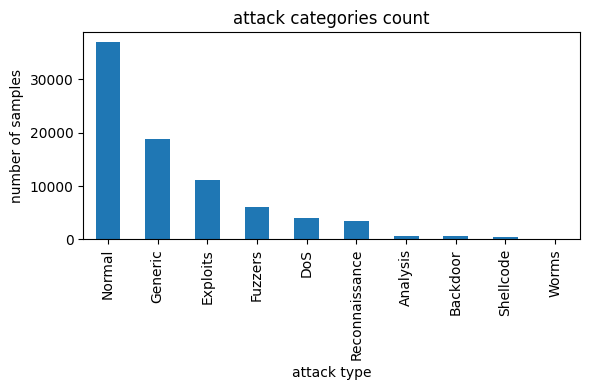

In [15]:
plt.figure(figsize=(6,4))
numoflabels.plot(kind="bar")
plt.title("attack categories count")
plt.xlabel("attack type")
plt.ylabel("number of samples")
plt.tight_layout()
plt.show()

In [16]:
num_col = df.select_dtypes(include=['int64', 'float64']).columns

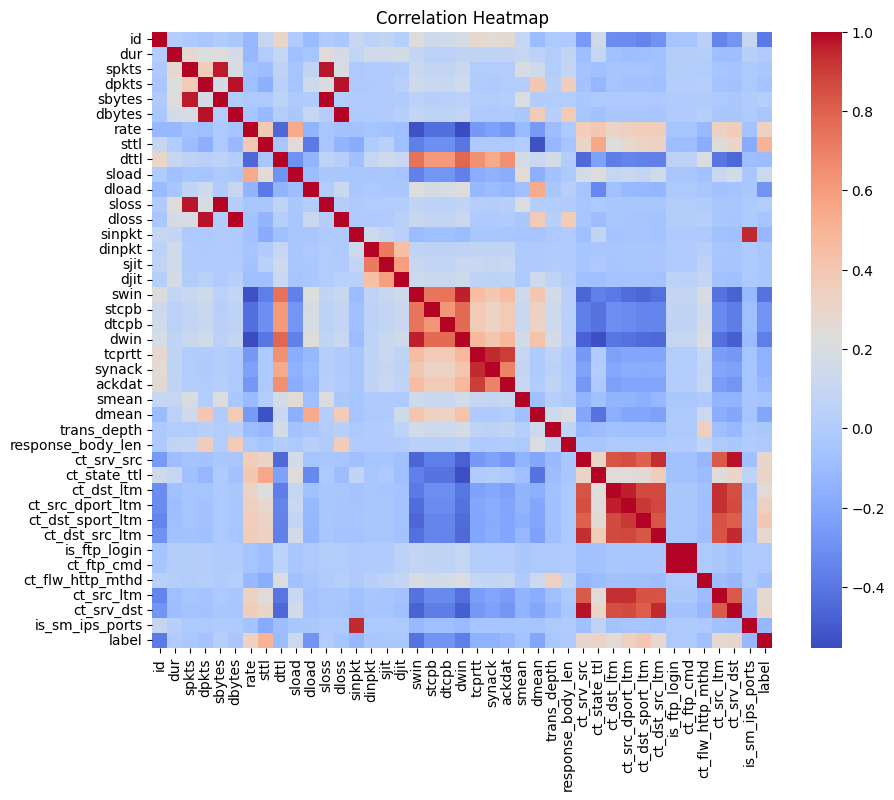

In [17]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df[num_col].corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

**histogram for the numeric features we have**


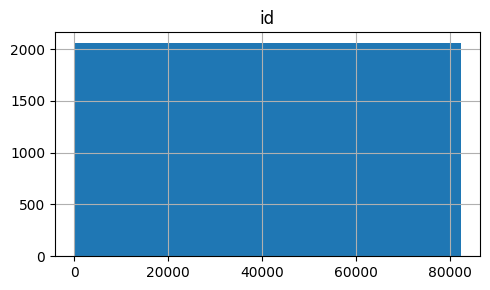

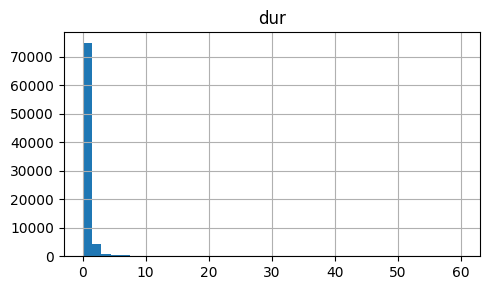

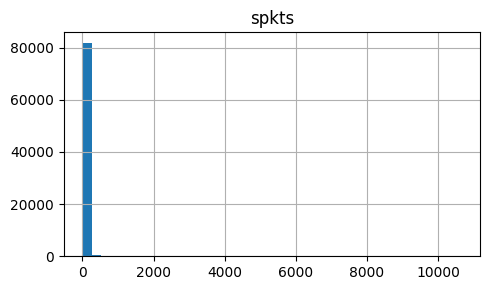

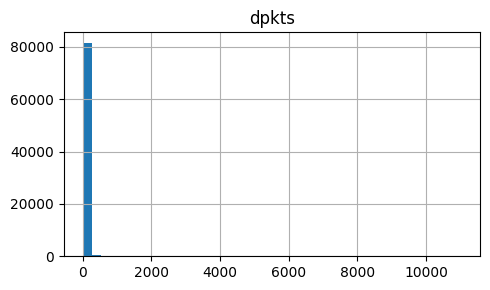

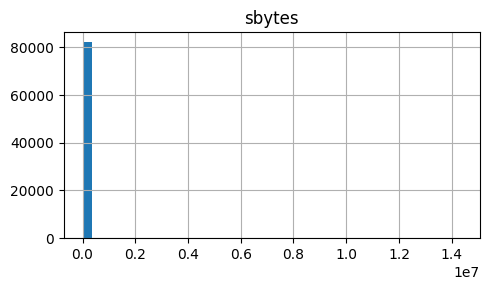

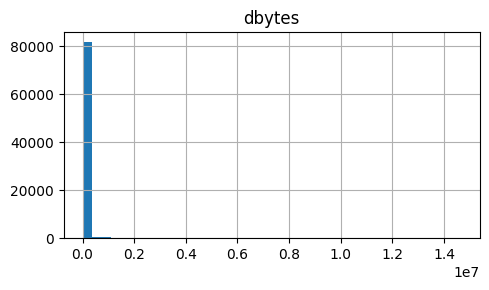

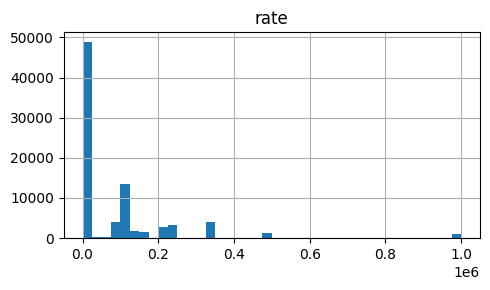

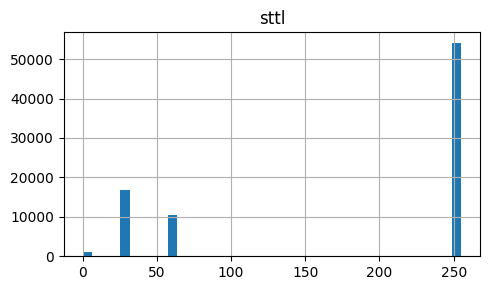

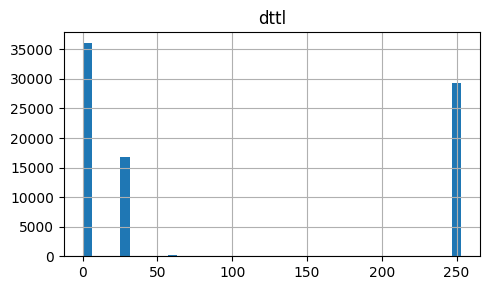

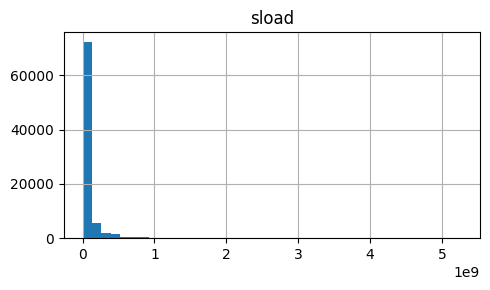

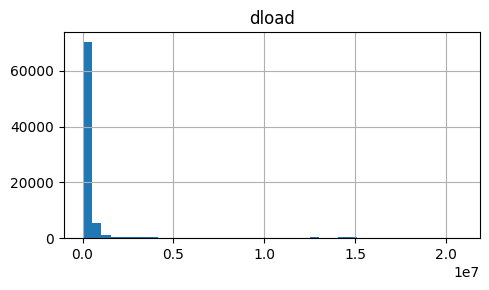

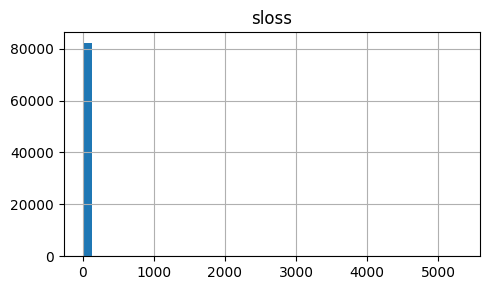

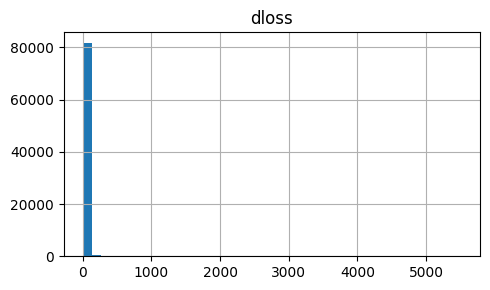

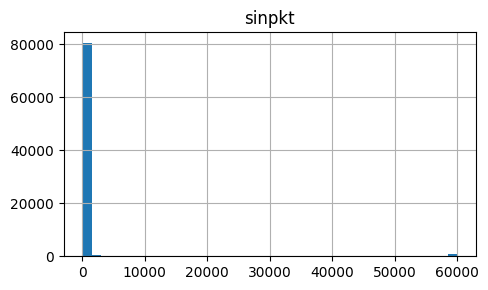

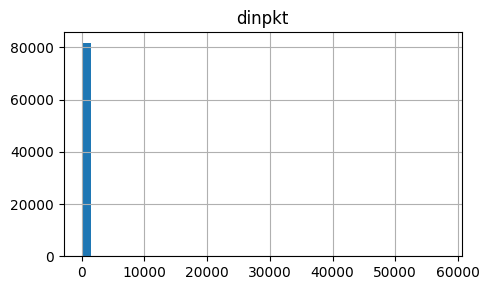

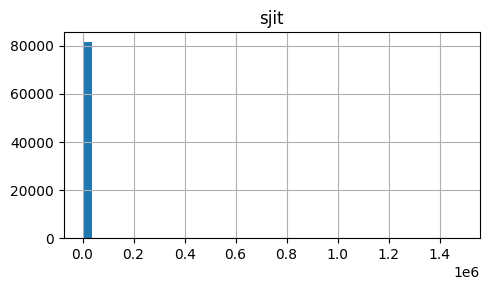

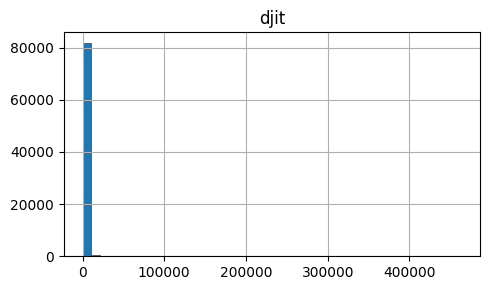

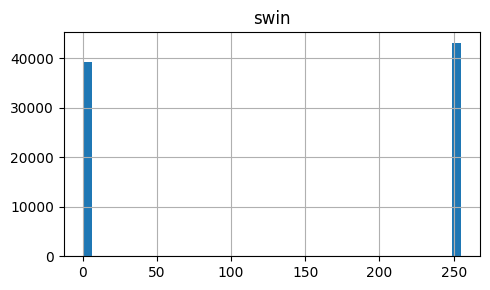

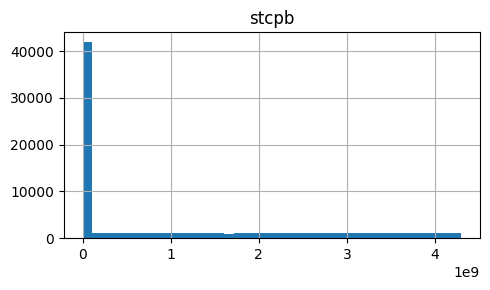

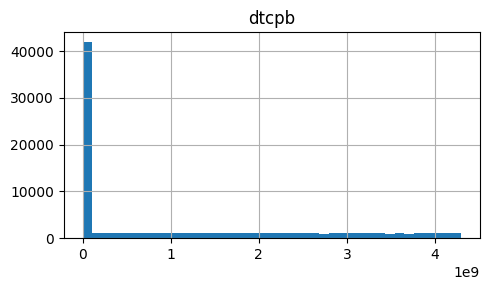

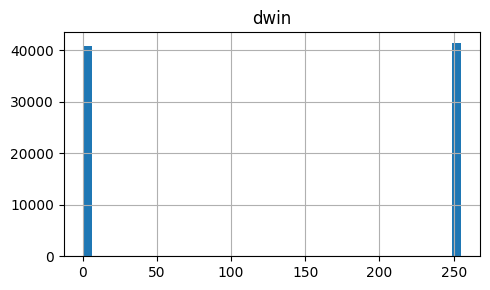

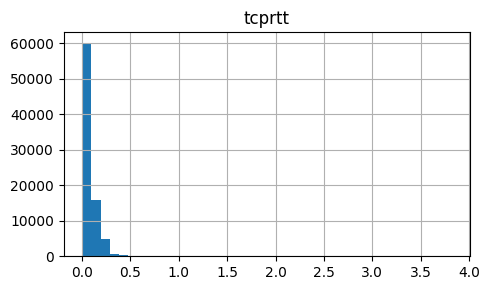

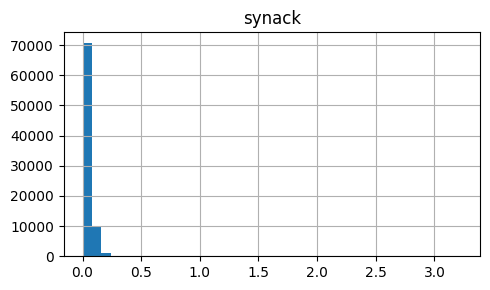

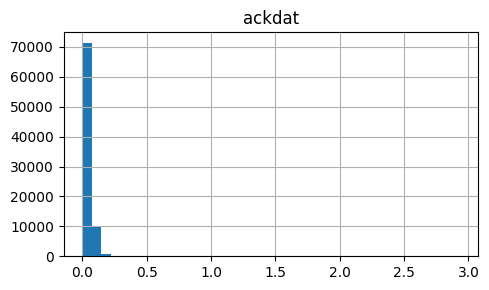

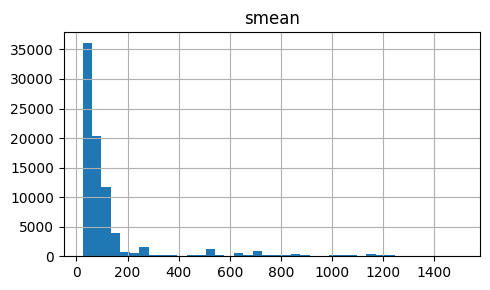

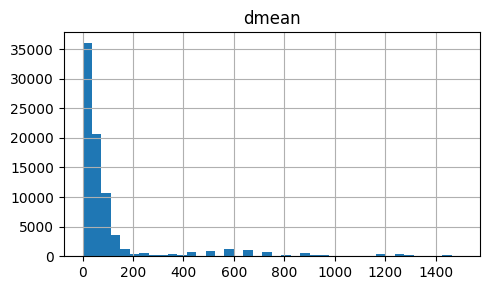

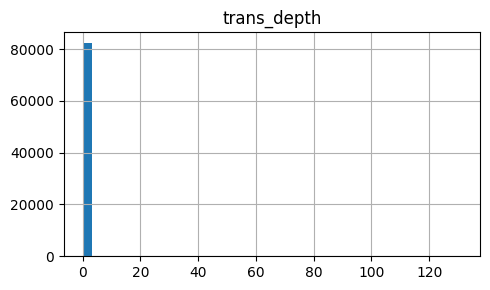

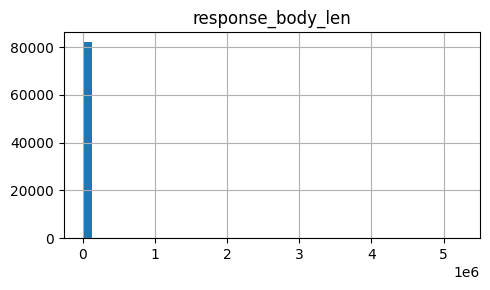

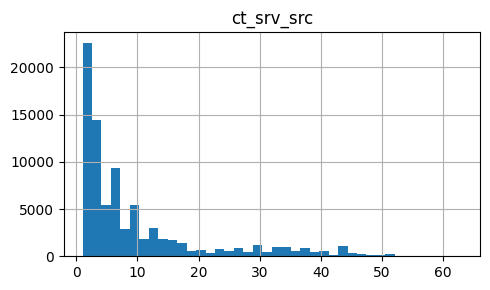

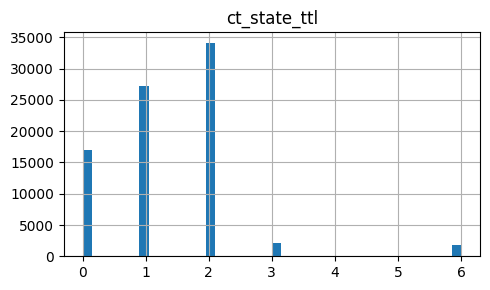

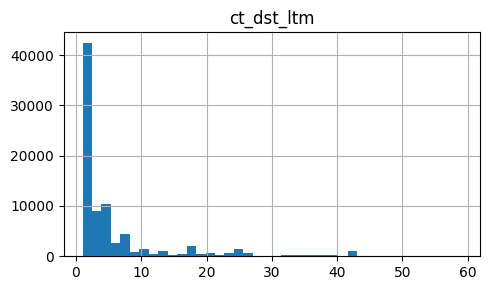

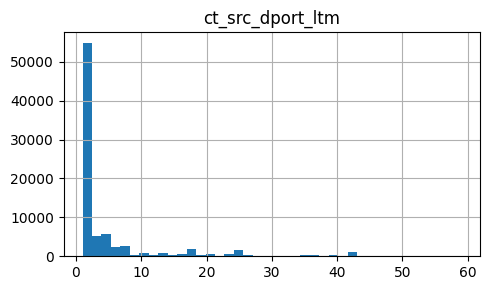

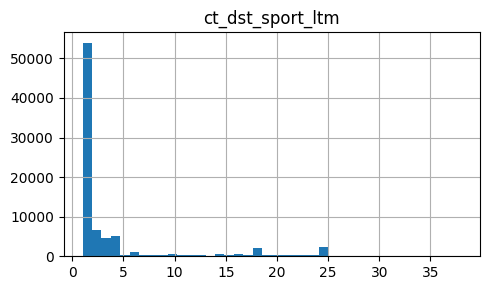

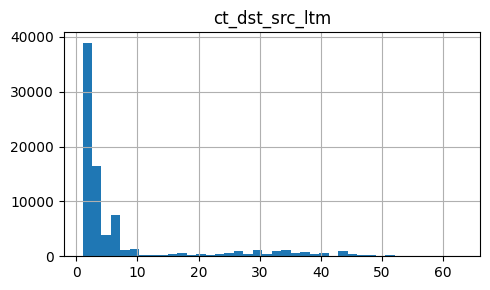

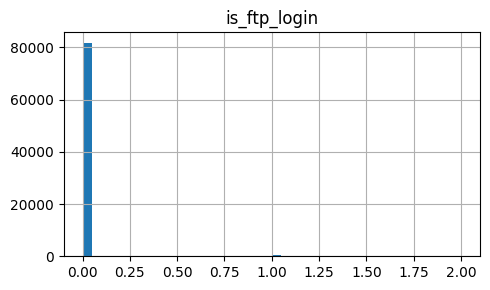

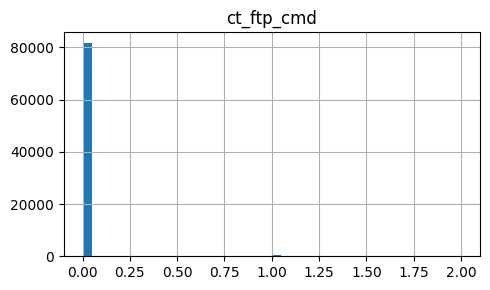

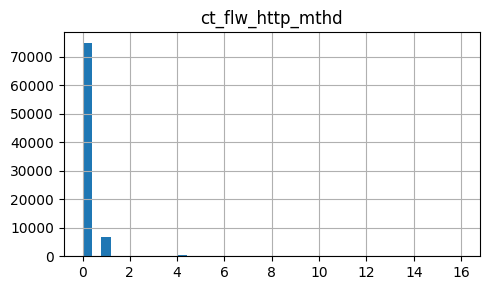

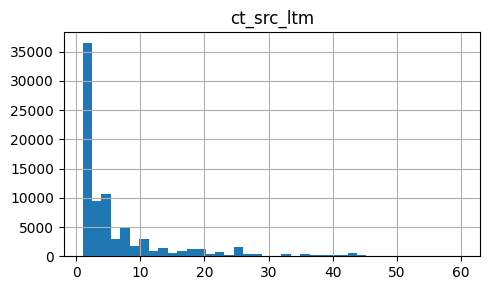

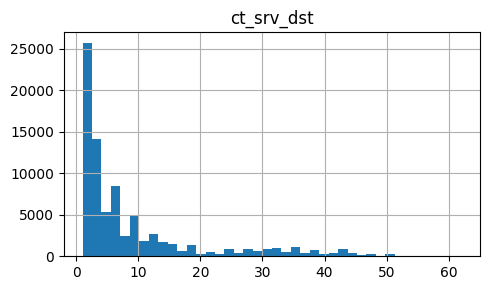

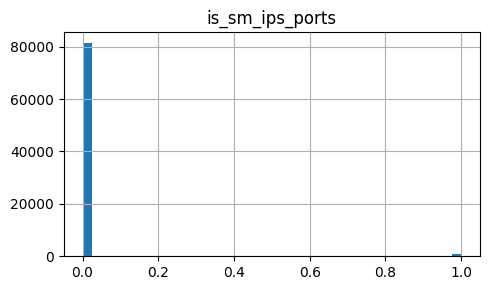

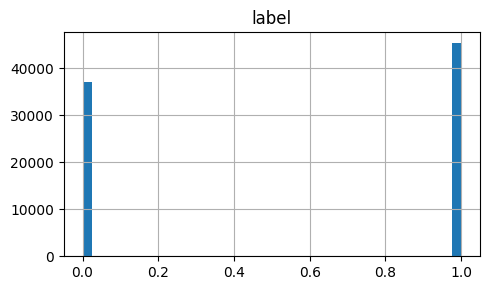

In [18]:
#hits for num features
for col in num_col:
    plt.figure(figsize=(5,3))
    df[col].hist(bins=40)
    plt.title(col)
    plt.tight_layout()
    plt.show()

**bar blot for the categorical features**


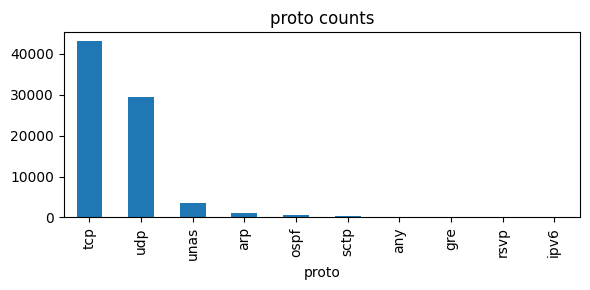

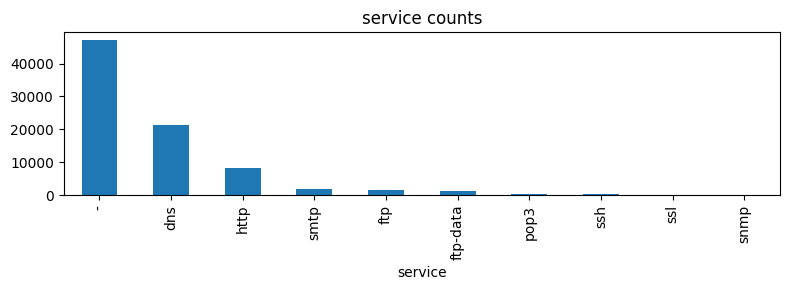

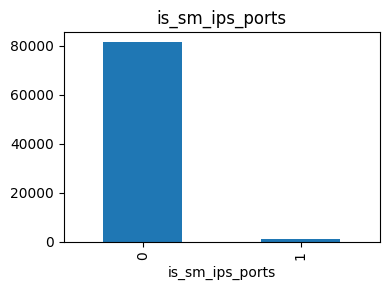

In [19]:
#we have 3 cat features (proto,service,is_sm_ips_ports)
plt.figure(figsize=(6,3))
df["proto"].value_counts().head(10).plot(kind="bar")
plt.title("proto counts")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,3))
df["service"].value_counts().head(10).plot(kind="bar")
plt.title("service counts")
plt.tight_layout()
plt.show()


plt.figure(figsize=(4,3))
df["is_sm_ips_ports"].value_counts().plot(kind="bar")
plt.title("is_sm_ips_ports")
plt.tight_layout()
plt.show()

plotted the duration for each attack type using a boxplot. we can clearly see behavioral differences between attack categories: for example DoS tends to have longer durations, Fuzzers are short bursts, while Normal traffic stays closer to the median range

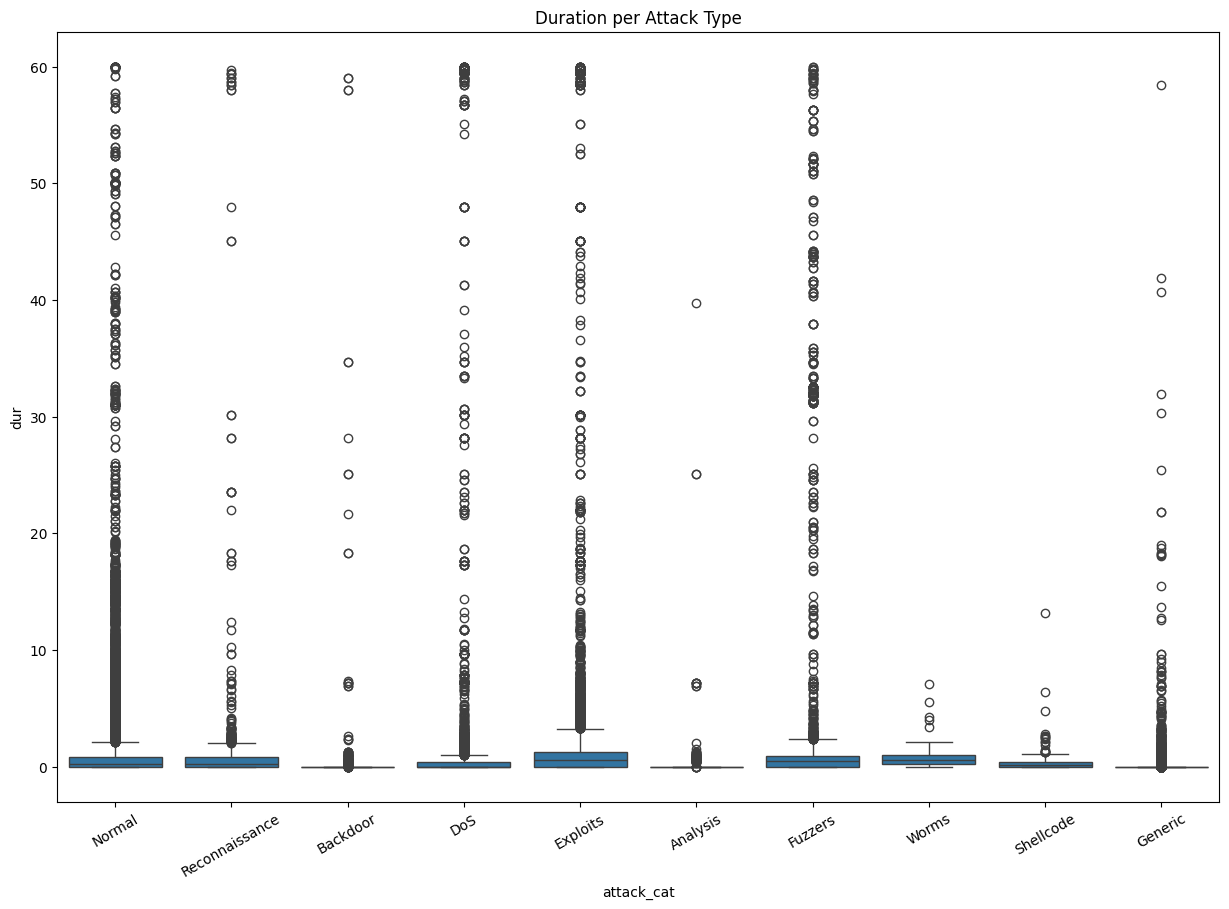

In [20]:
plt.figure(figsize=(15,10))
sns.boxplot(data=df, x="attack_cat", y="dur")
plt.xticks(rotation=30)
plt.title("Duration per Attack Type")
plt.show()

The boxplot shows that the duration feature varies significantly across different attack categories. Attacks such as Exploits, Worms, and Fuzzers tend to have longer and more dispersed durations, while Backdoor and Analysis attacks are generally short-lived. **This indicates that duration is a discriminative feature for attack classification.**

box plot for each feature

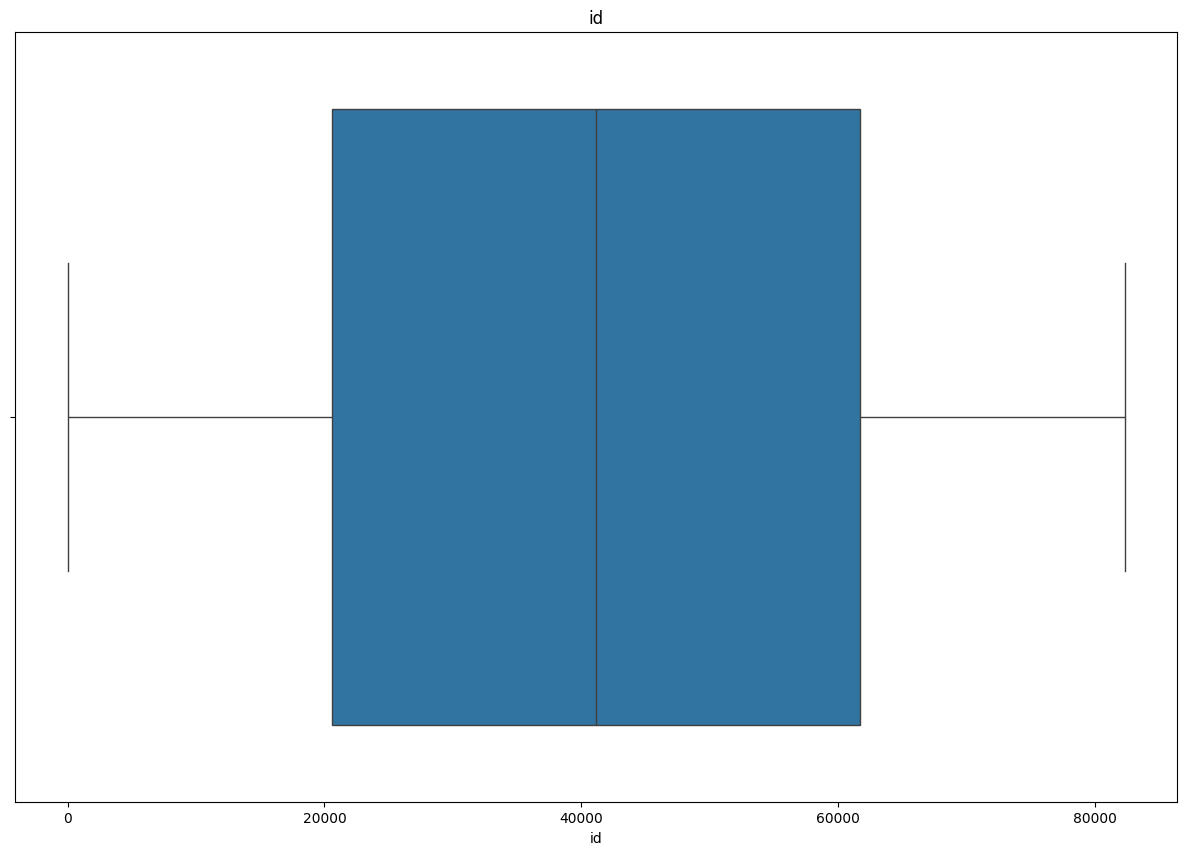

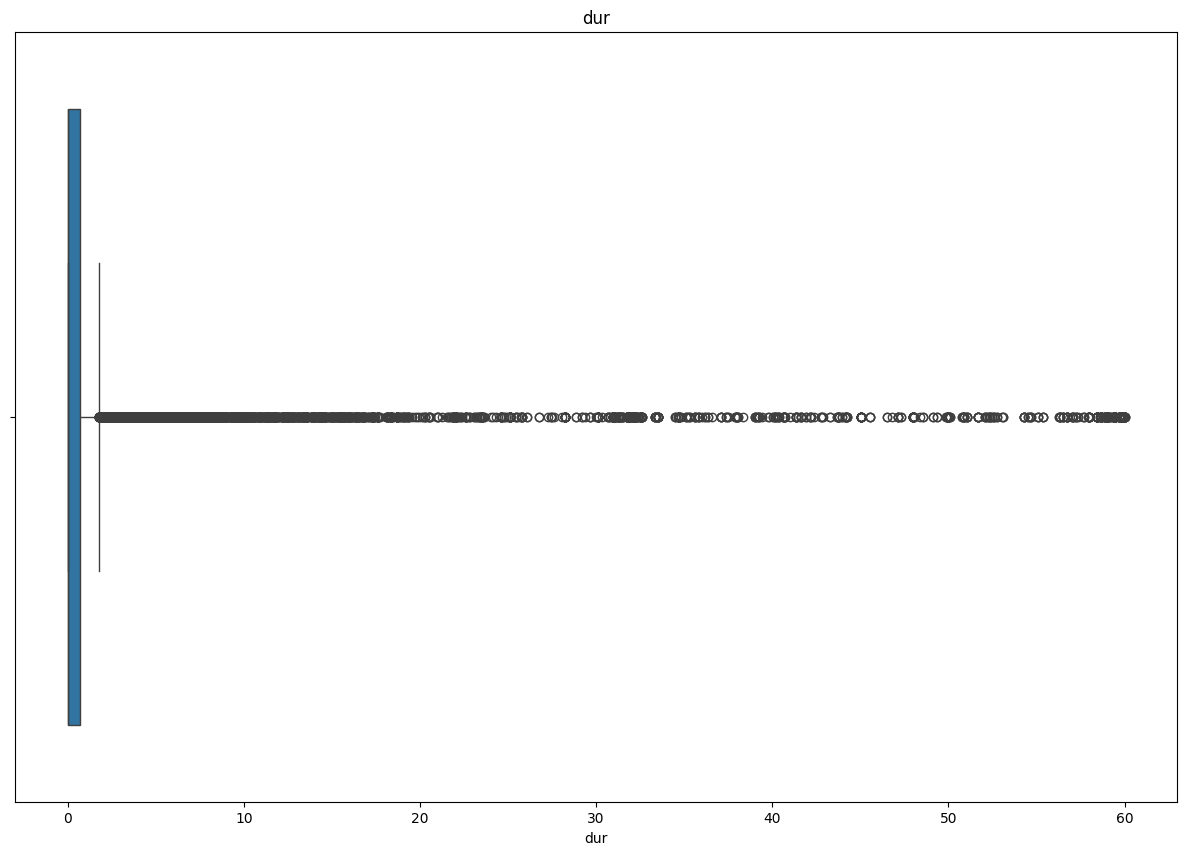

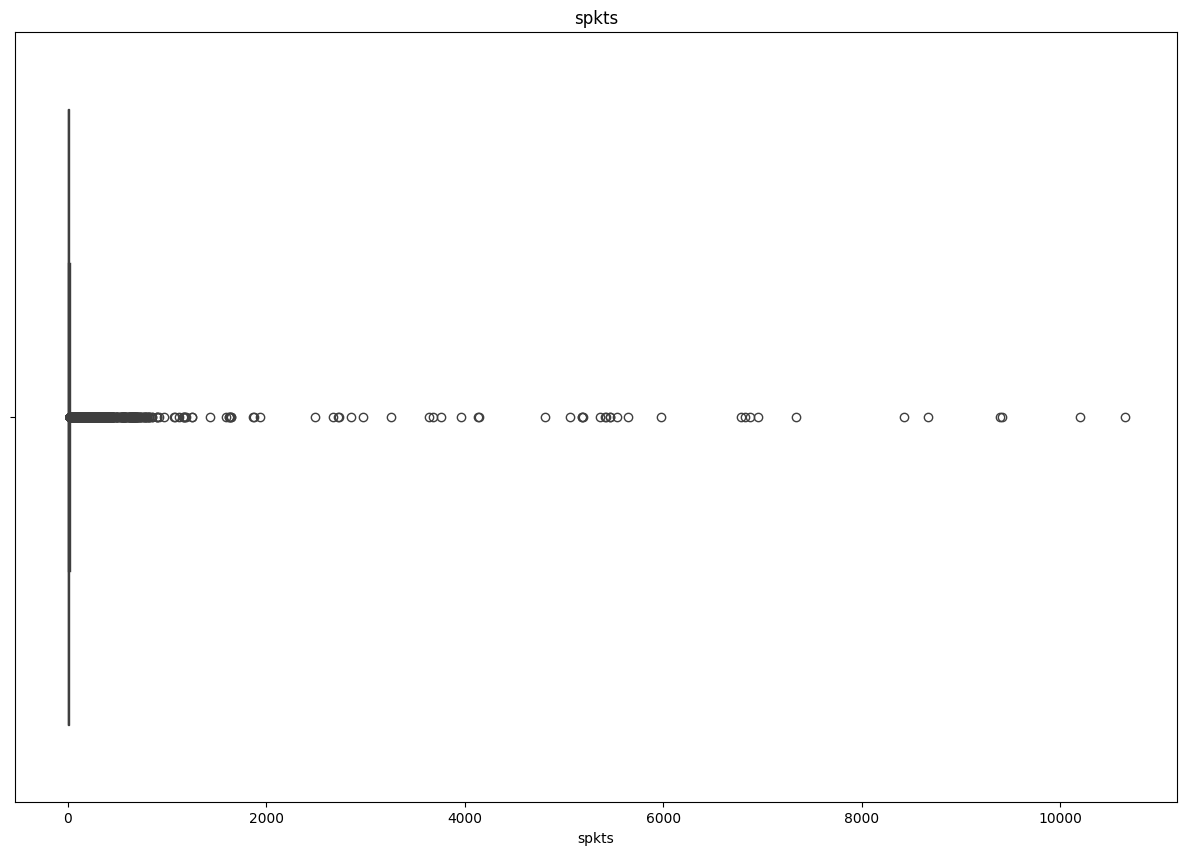

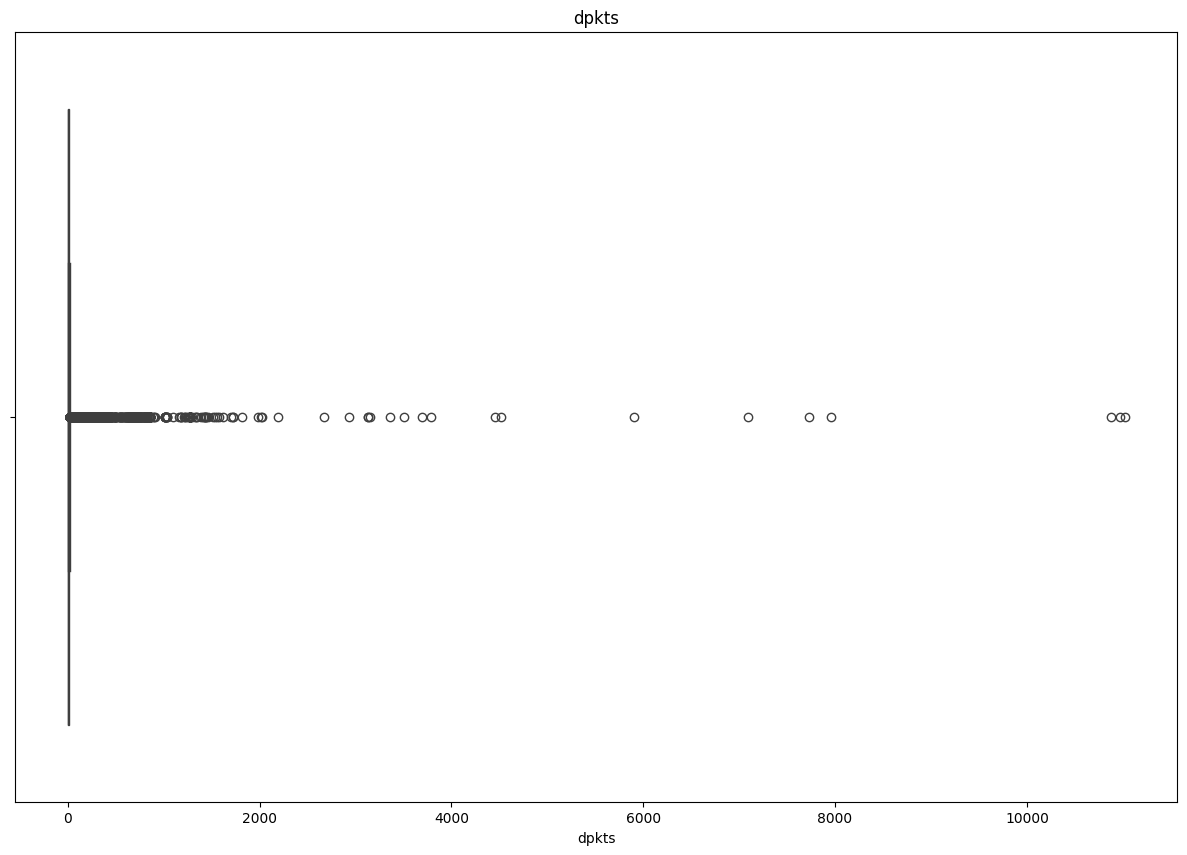

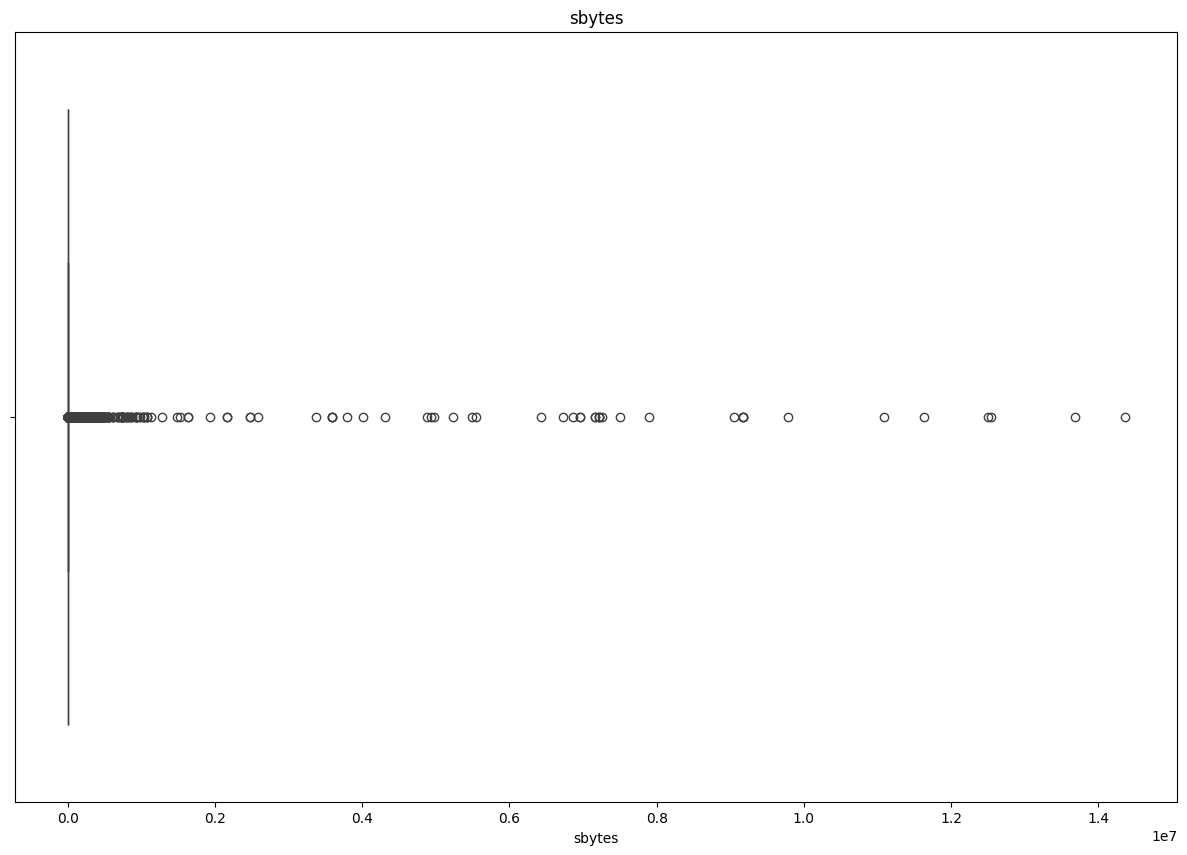

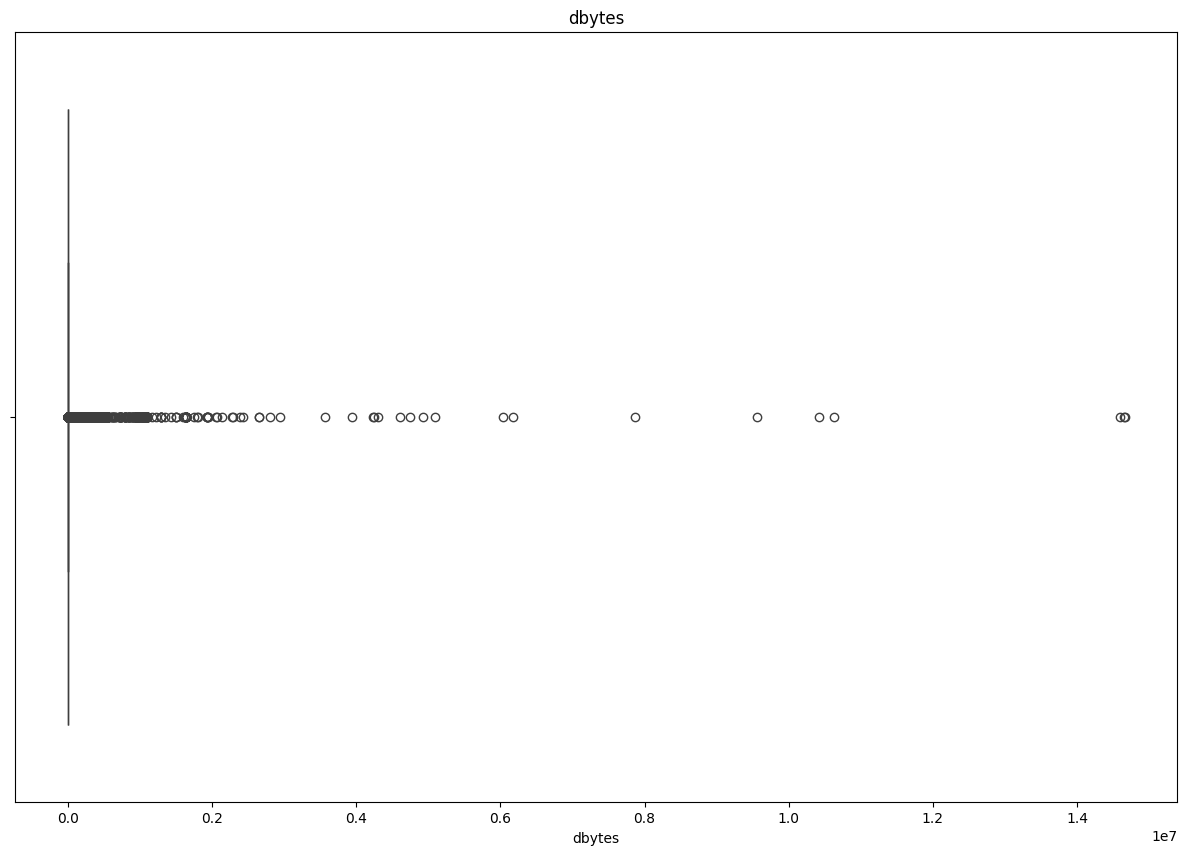

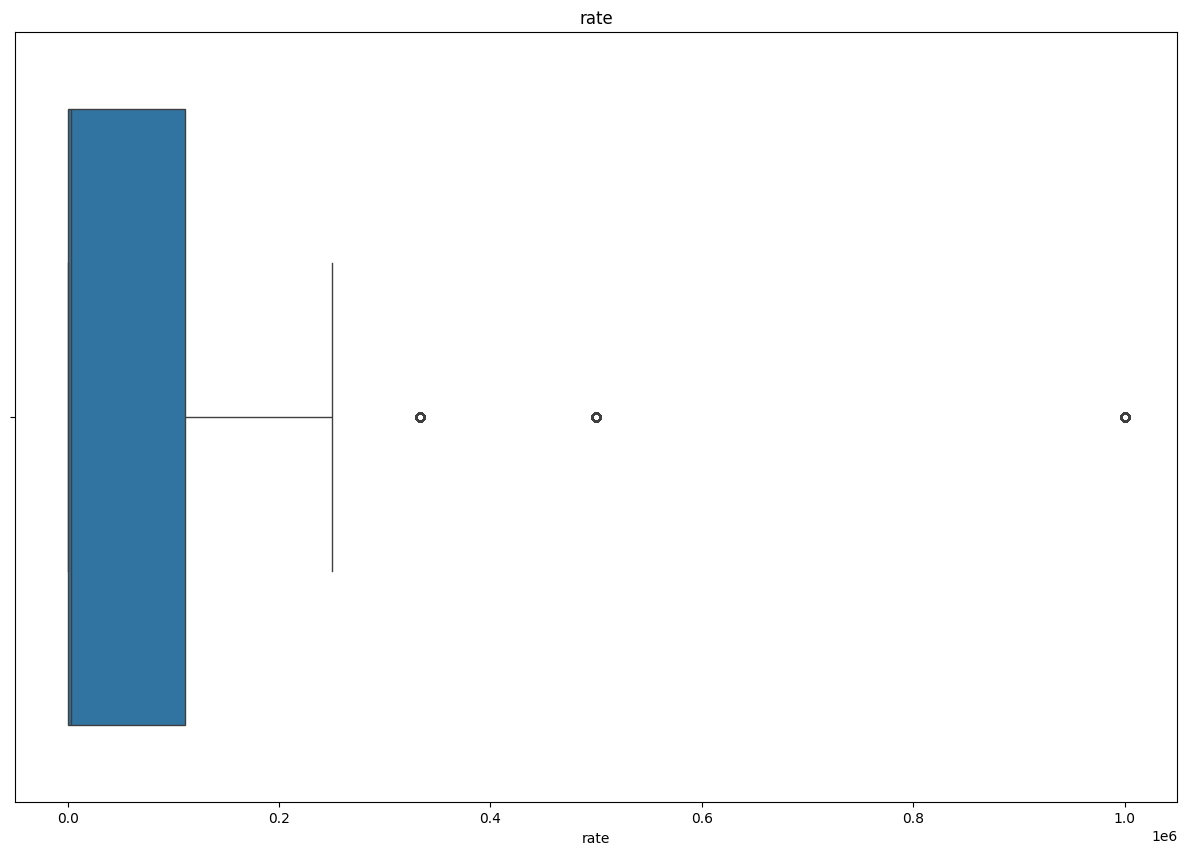

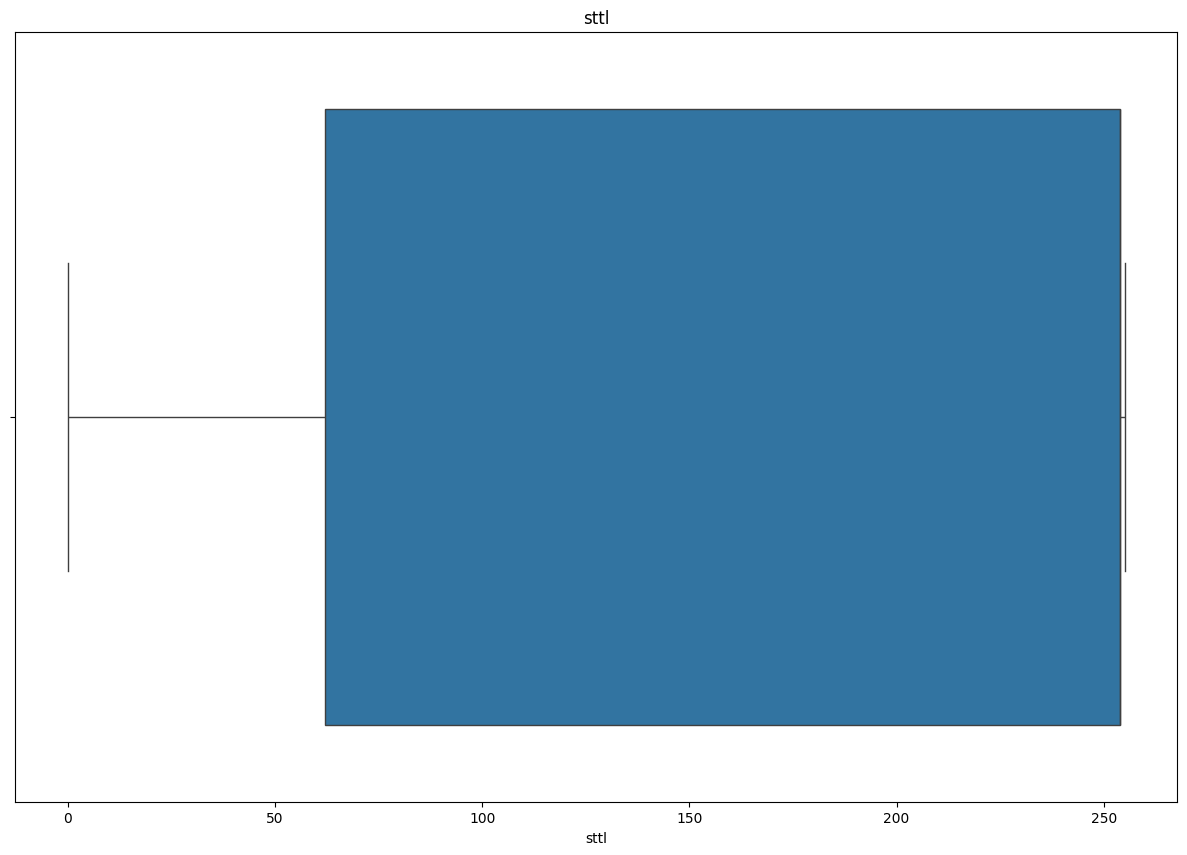

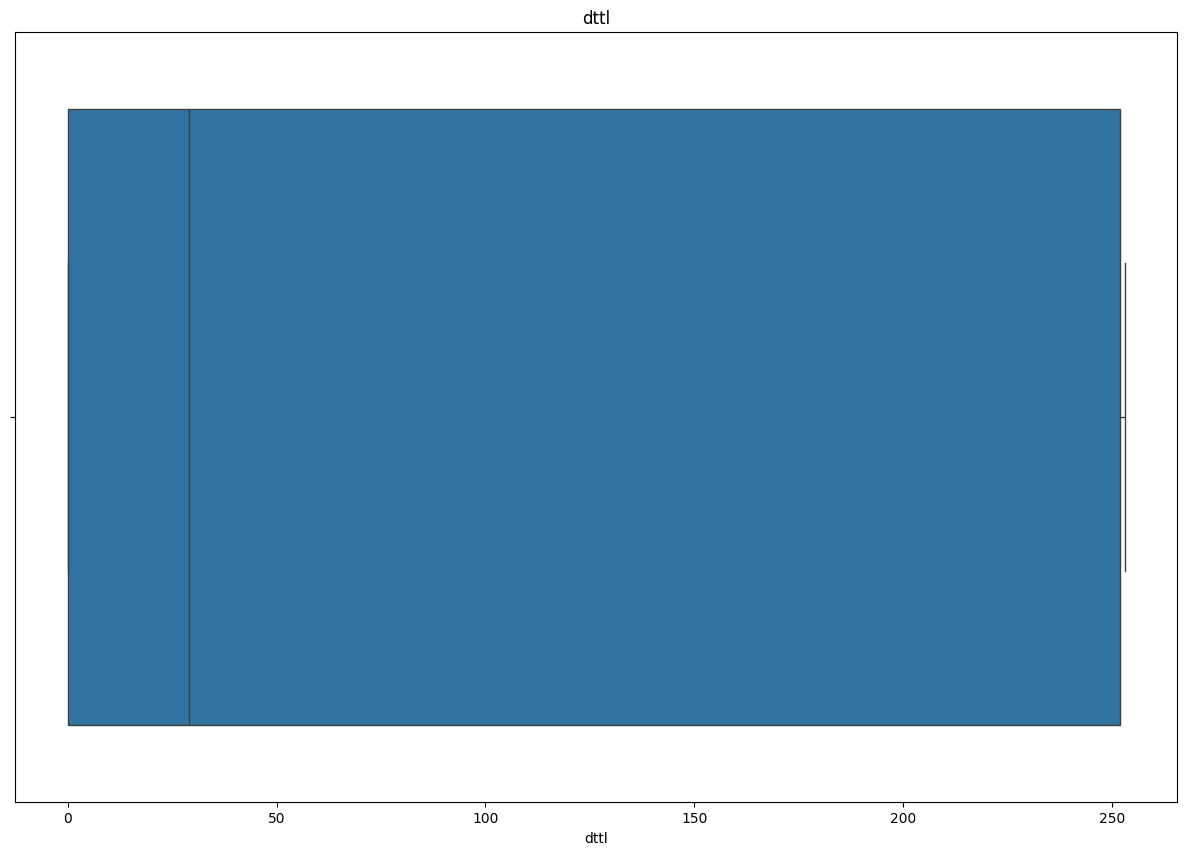

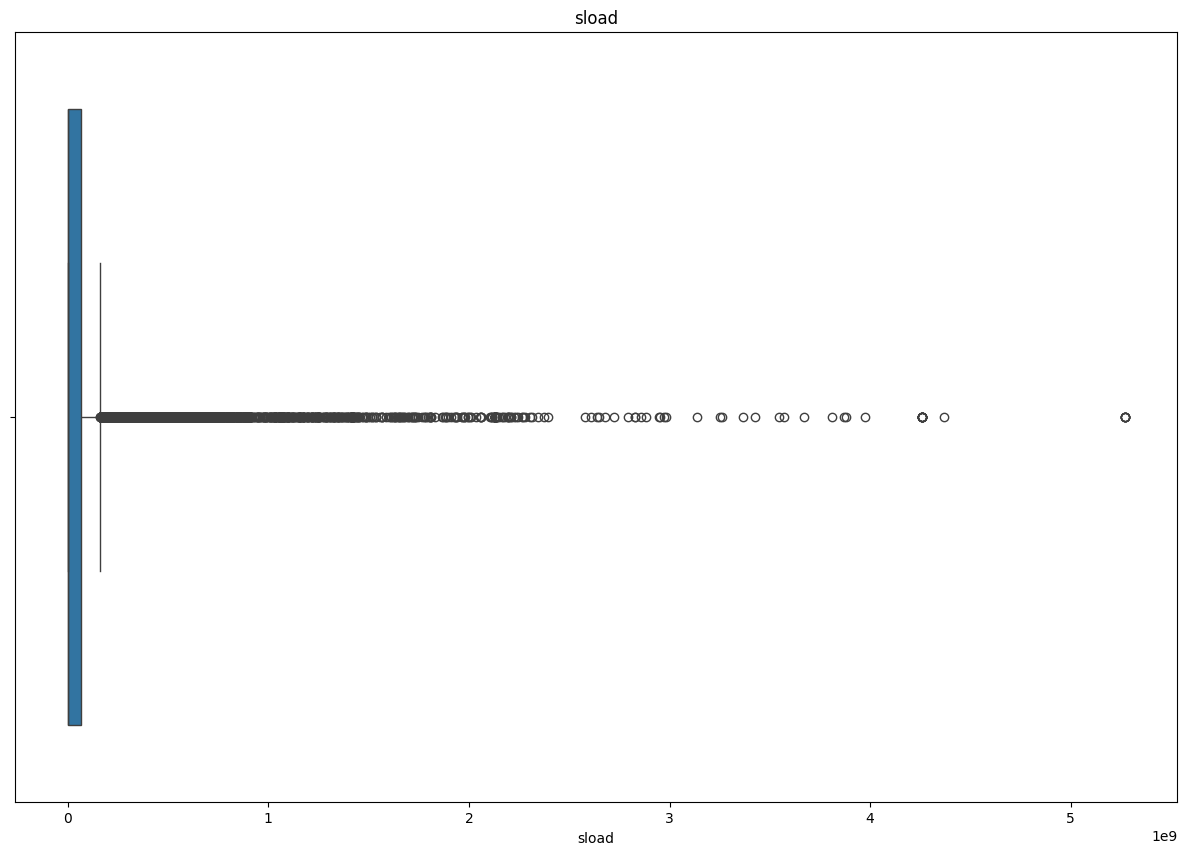

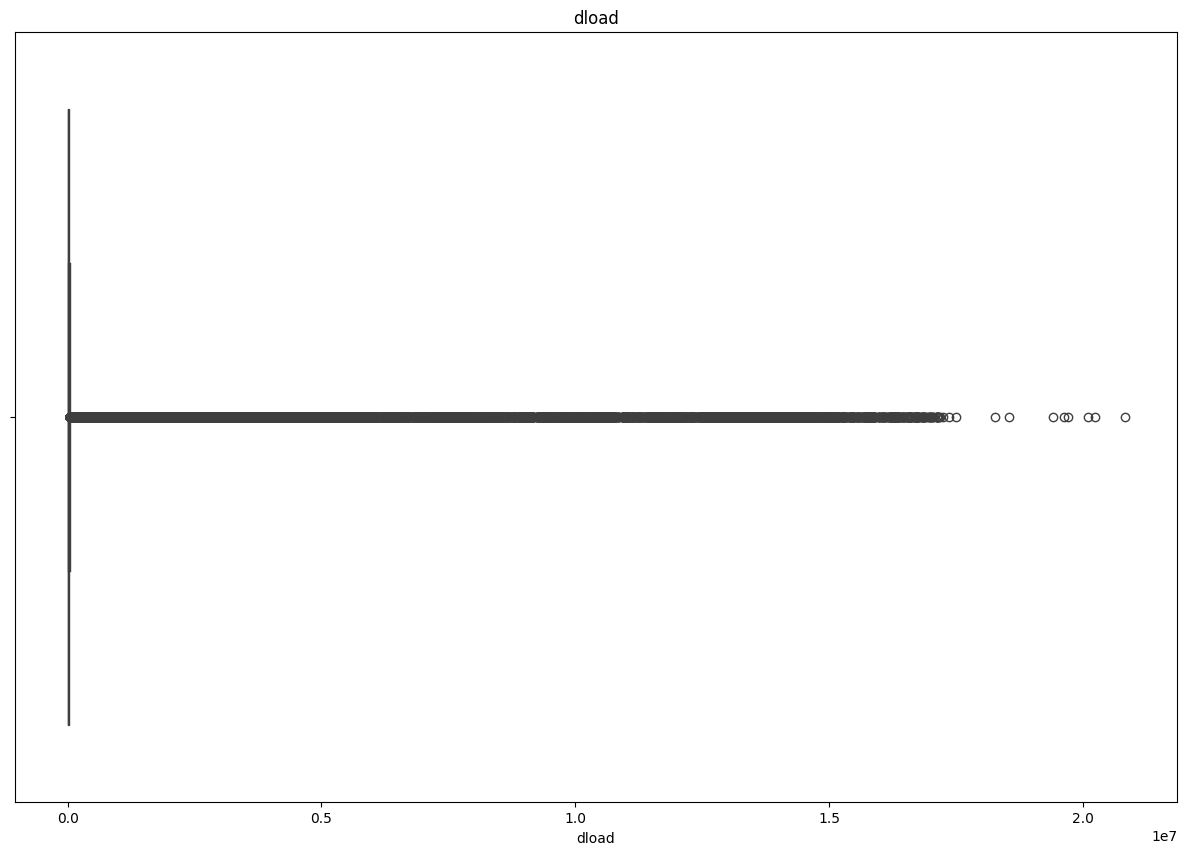

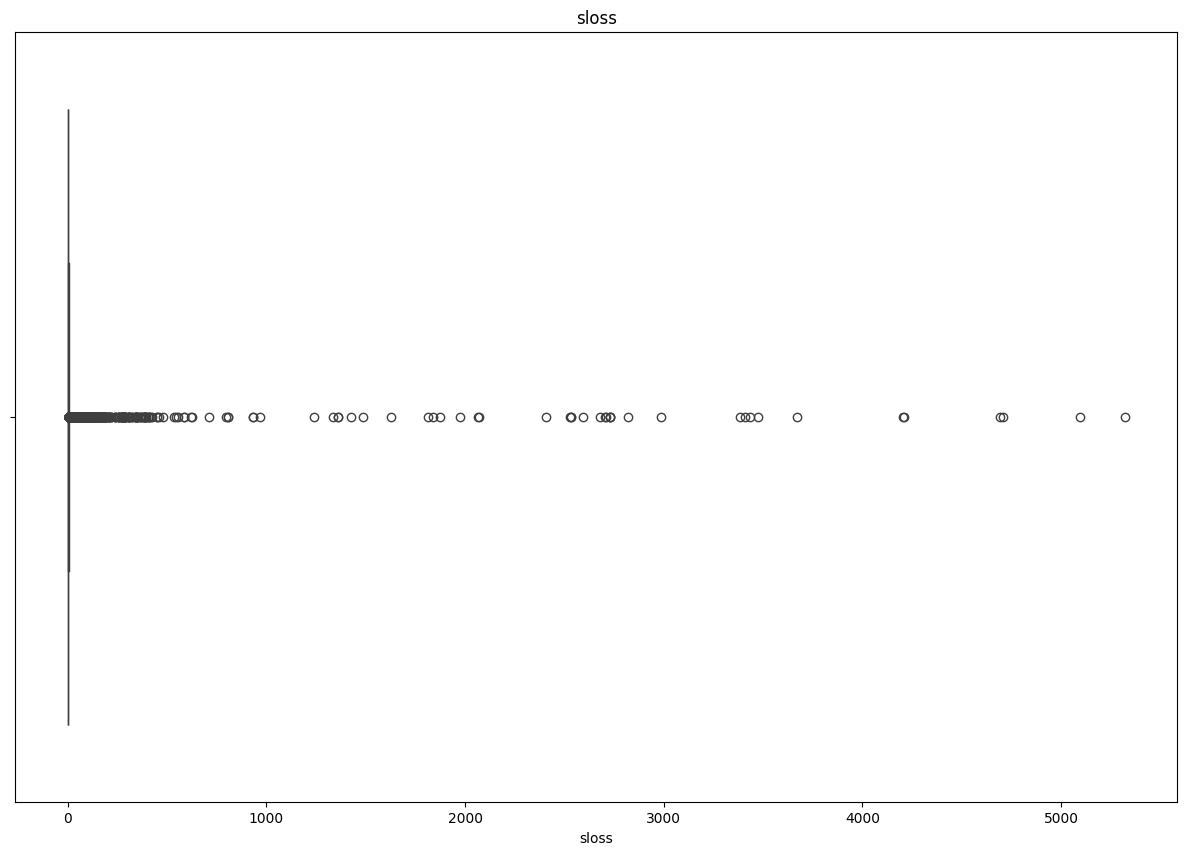

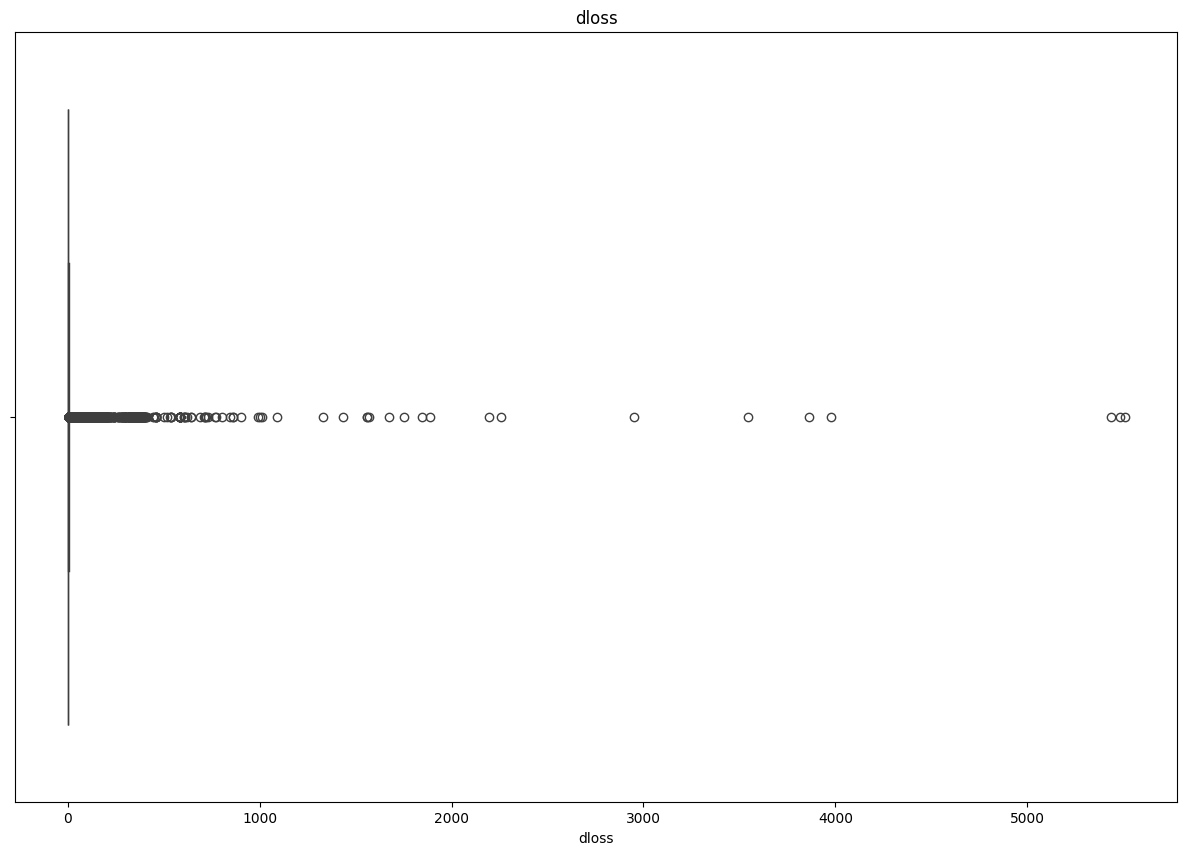

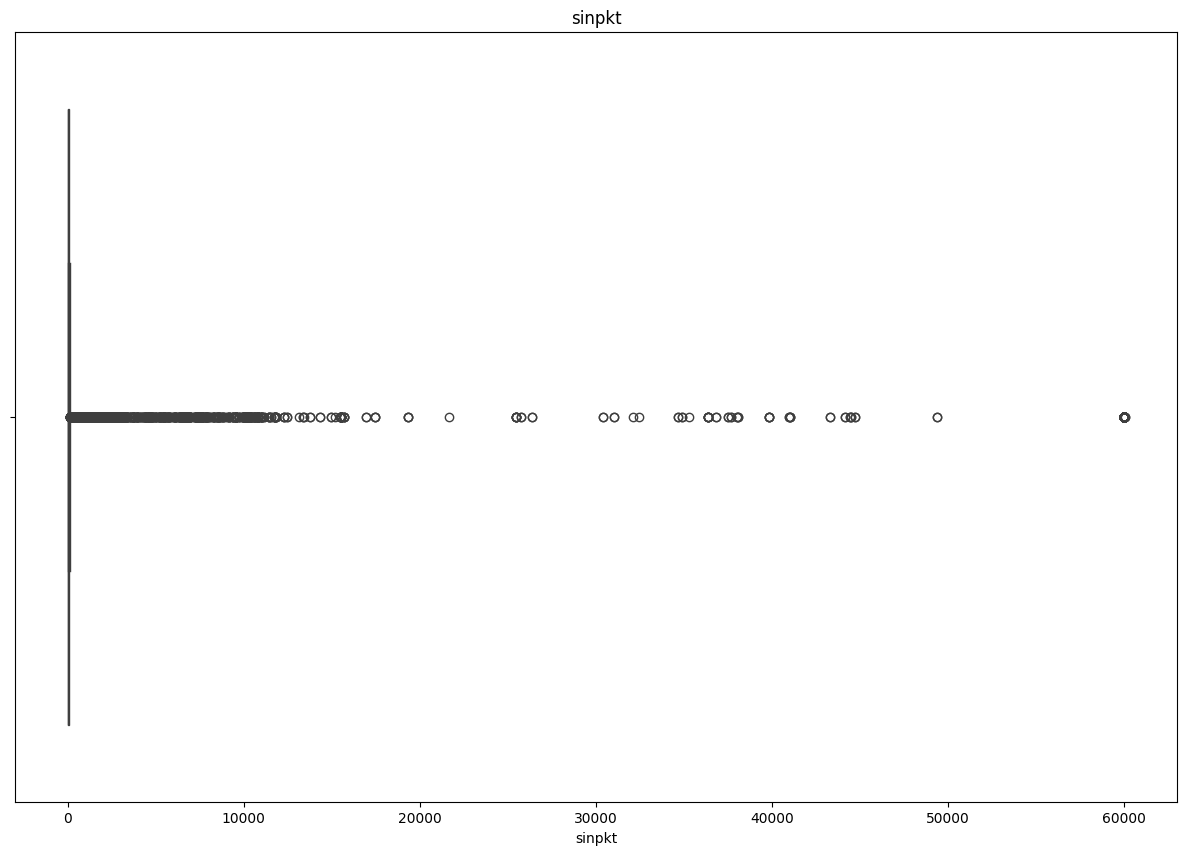

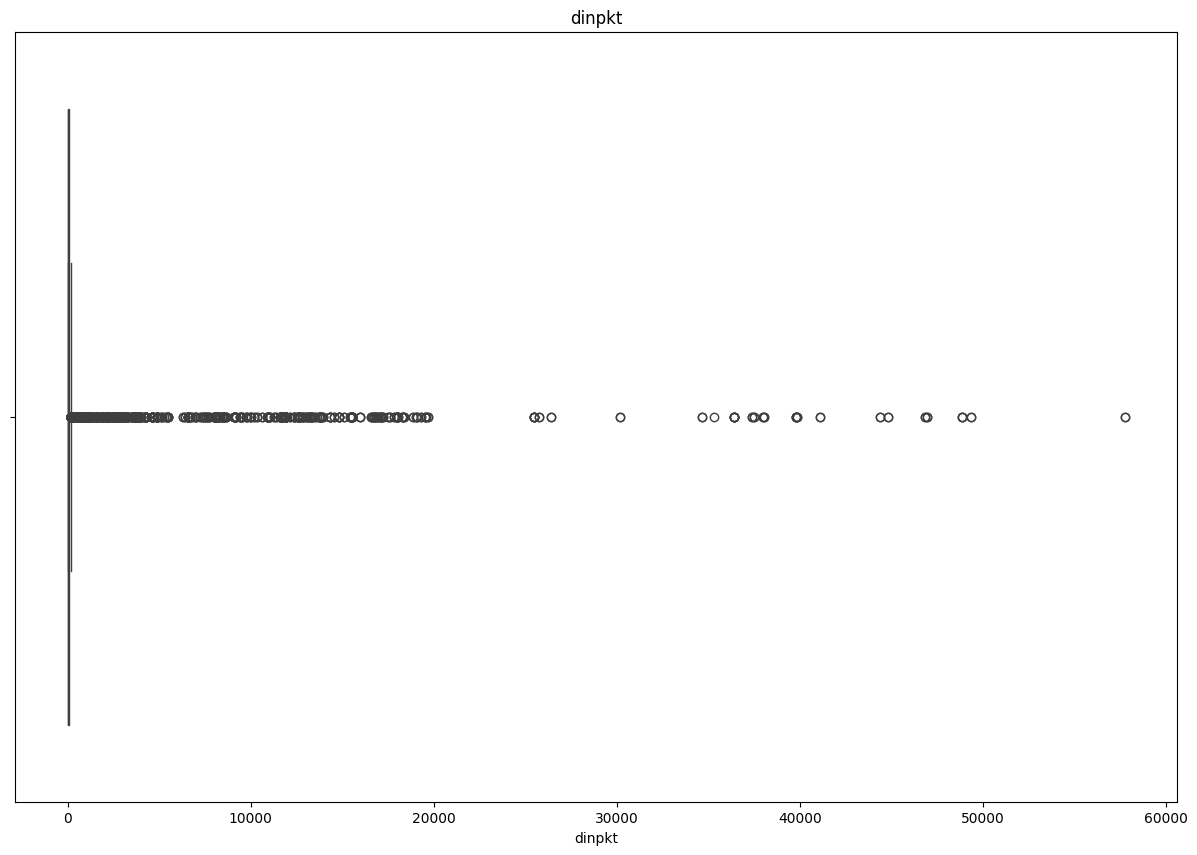

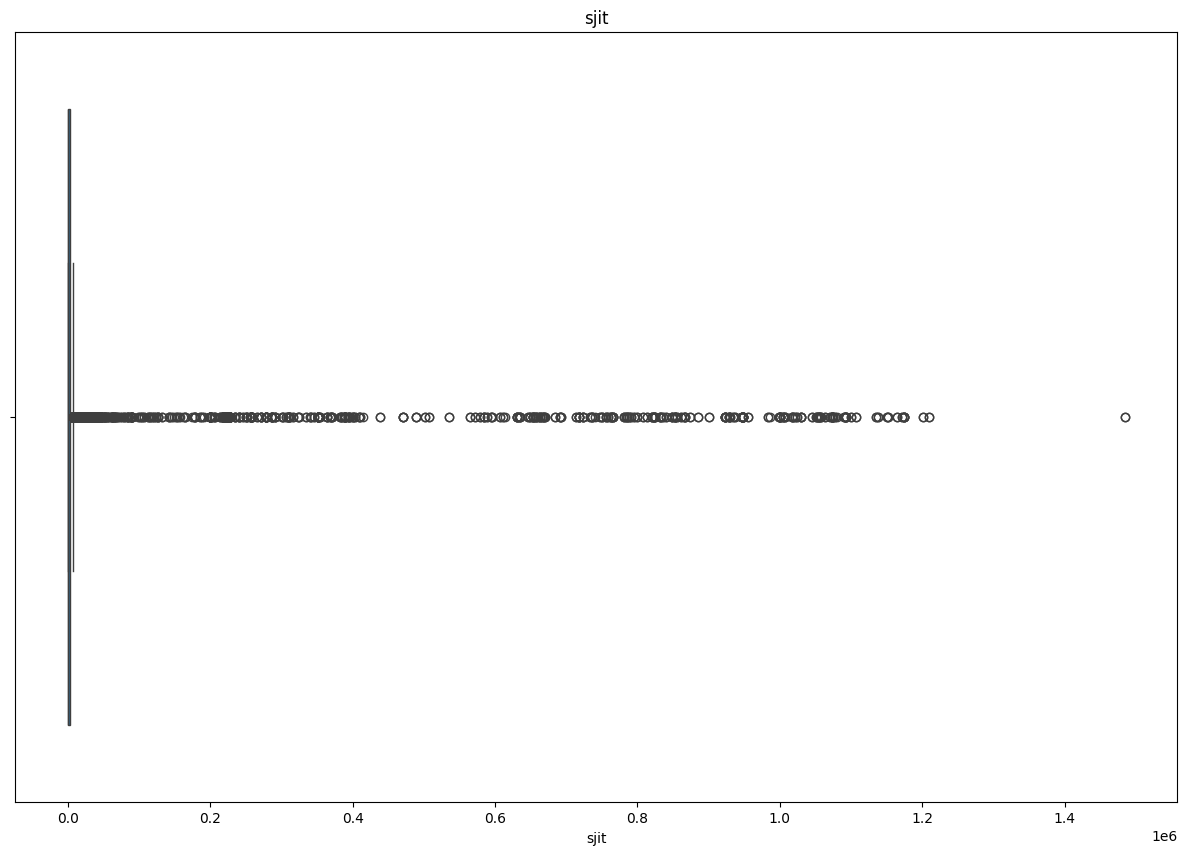

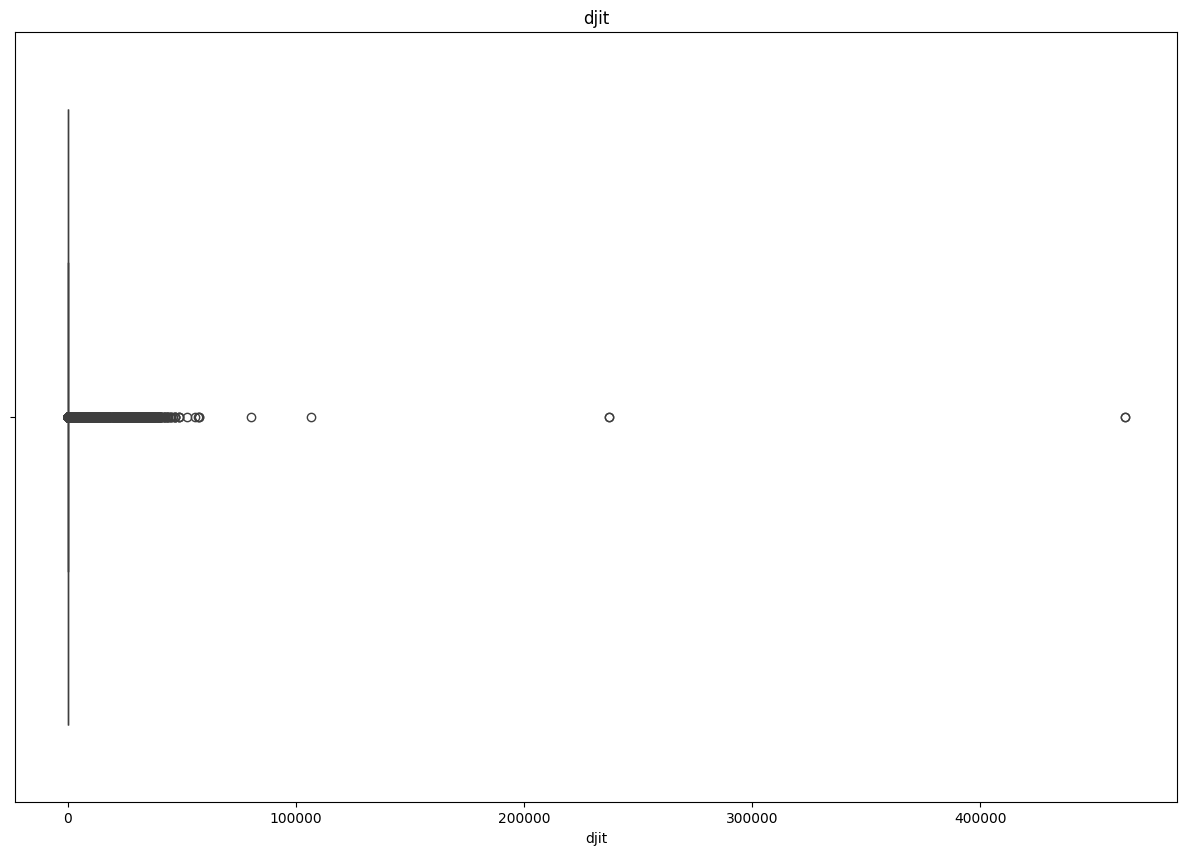

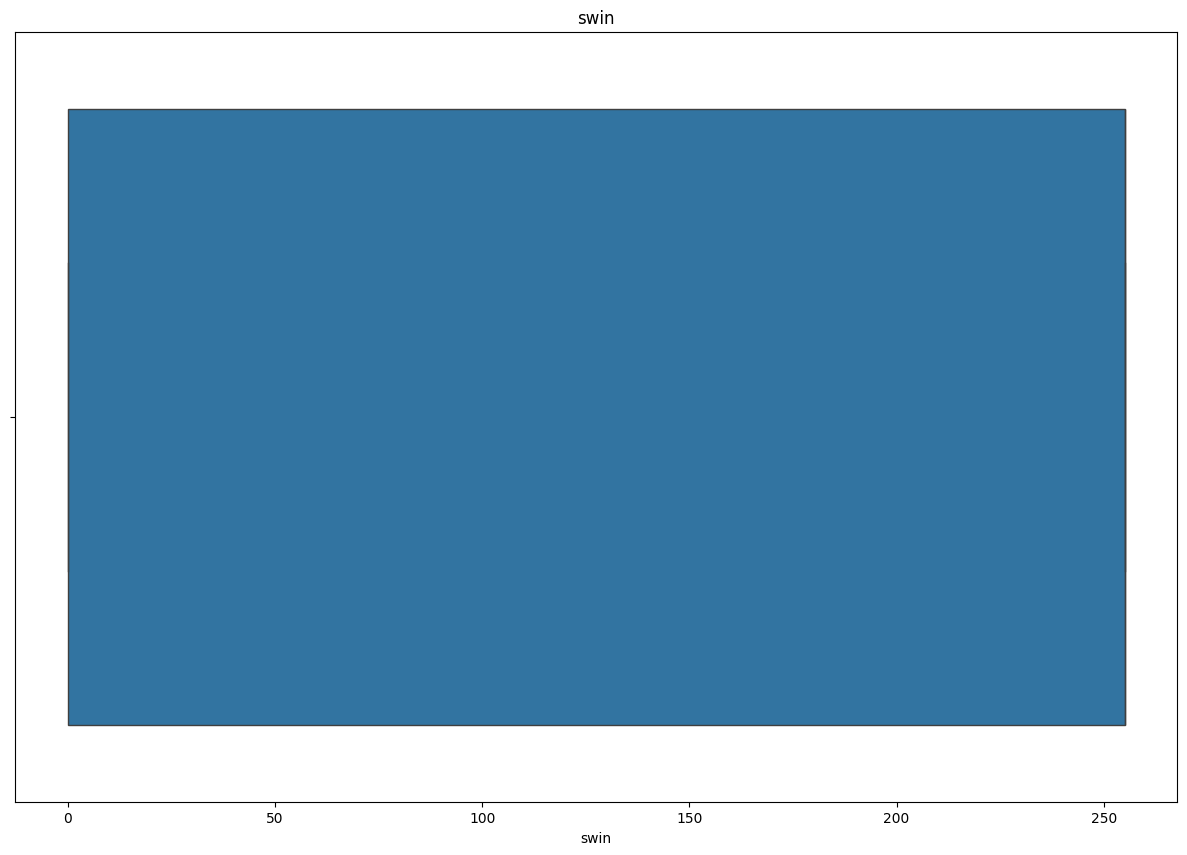

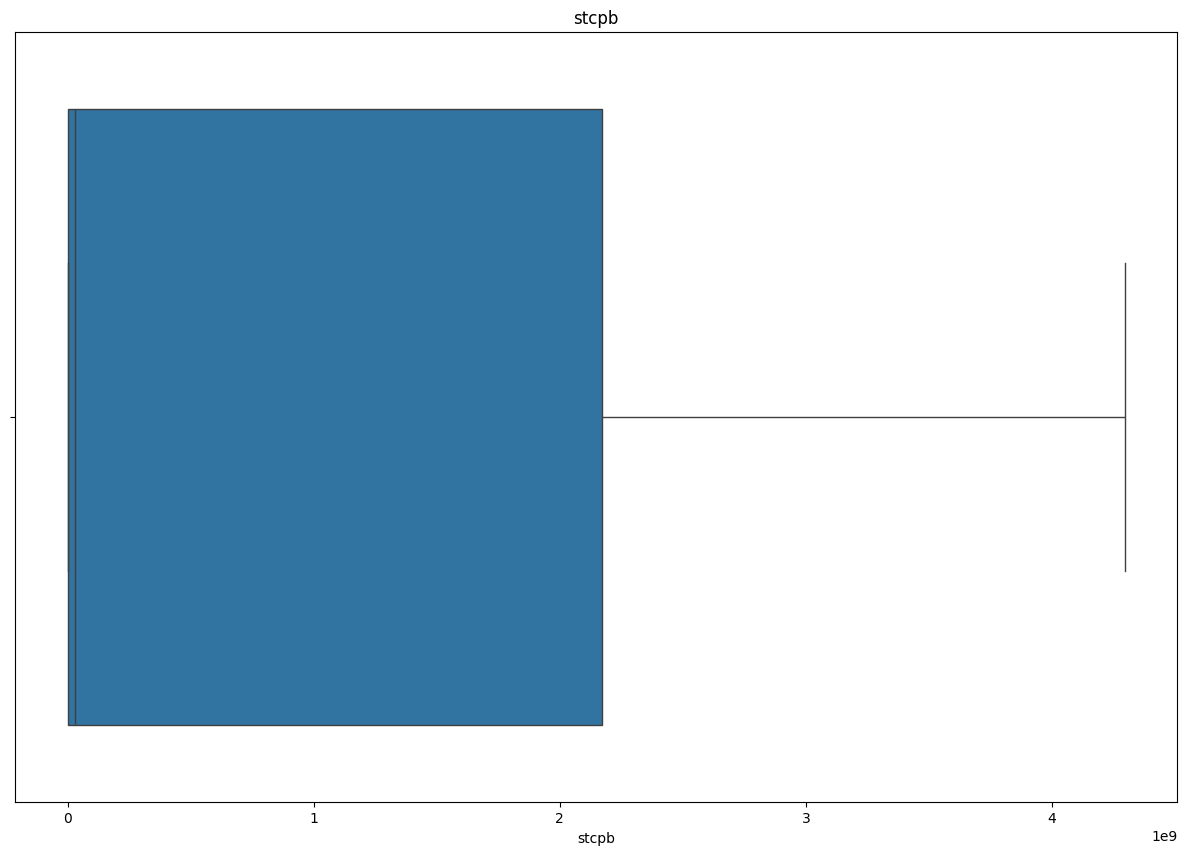

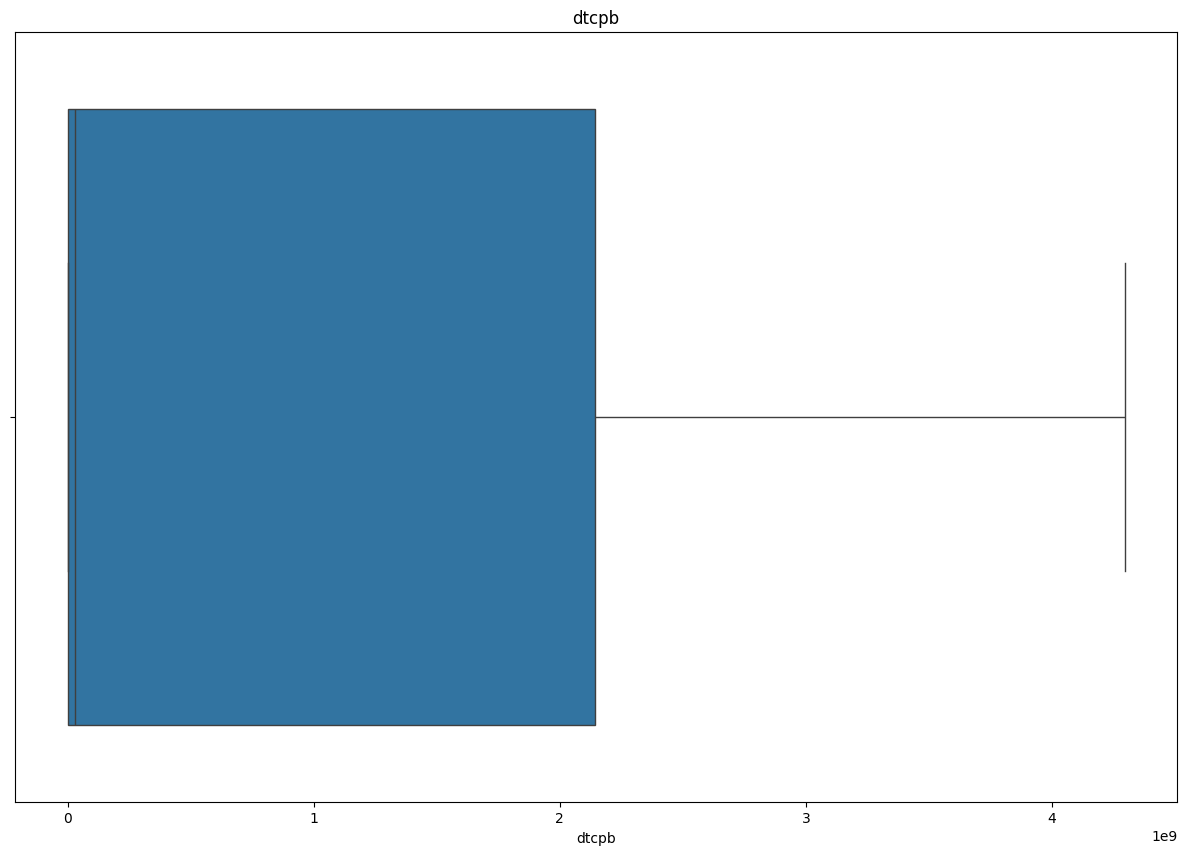

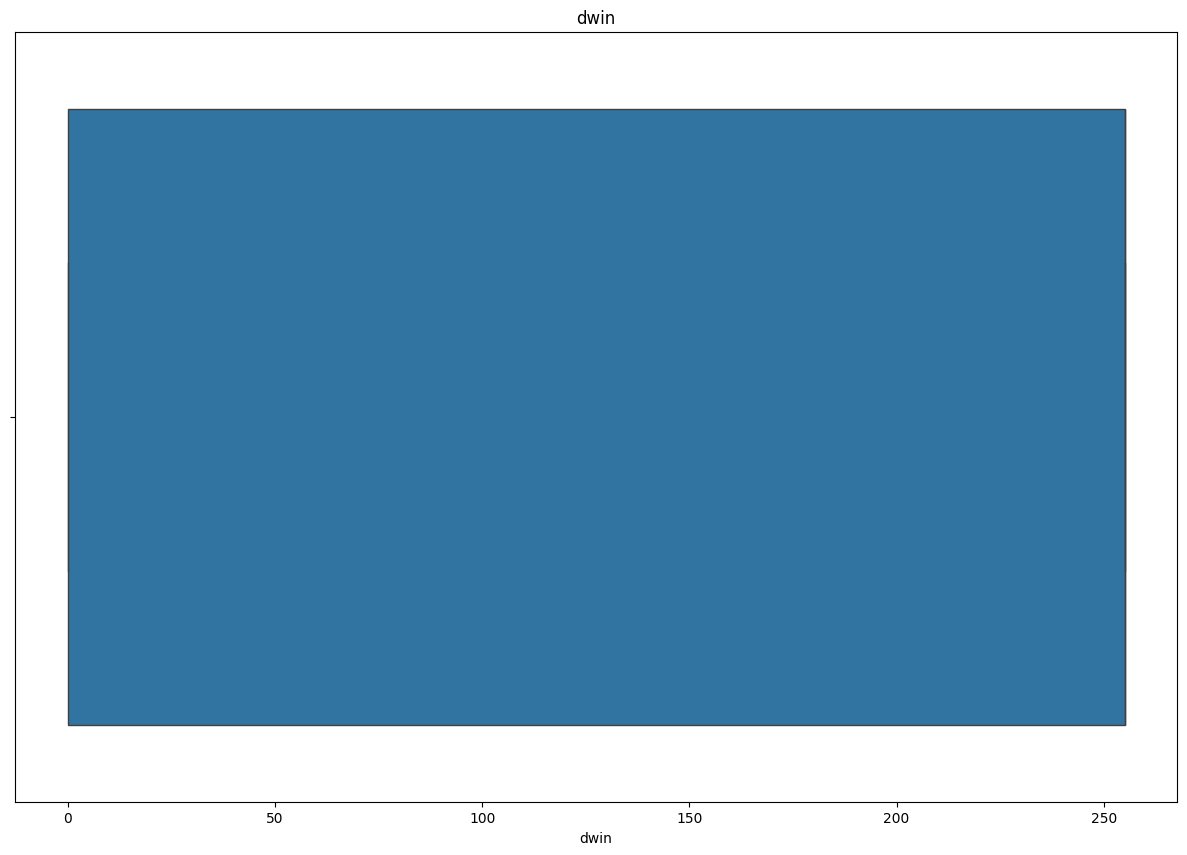

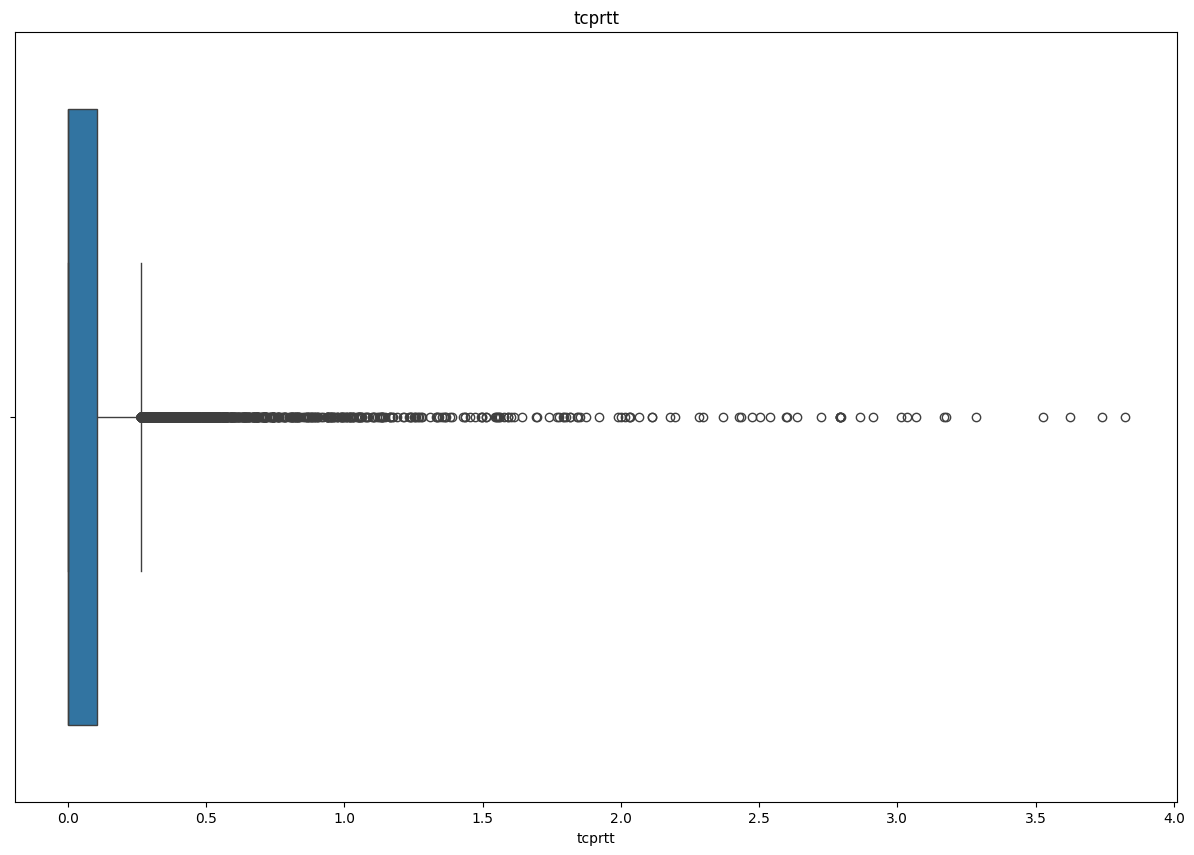

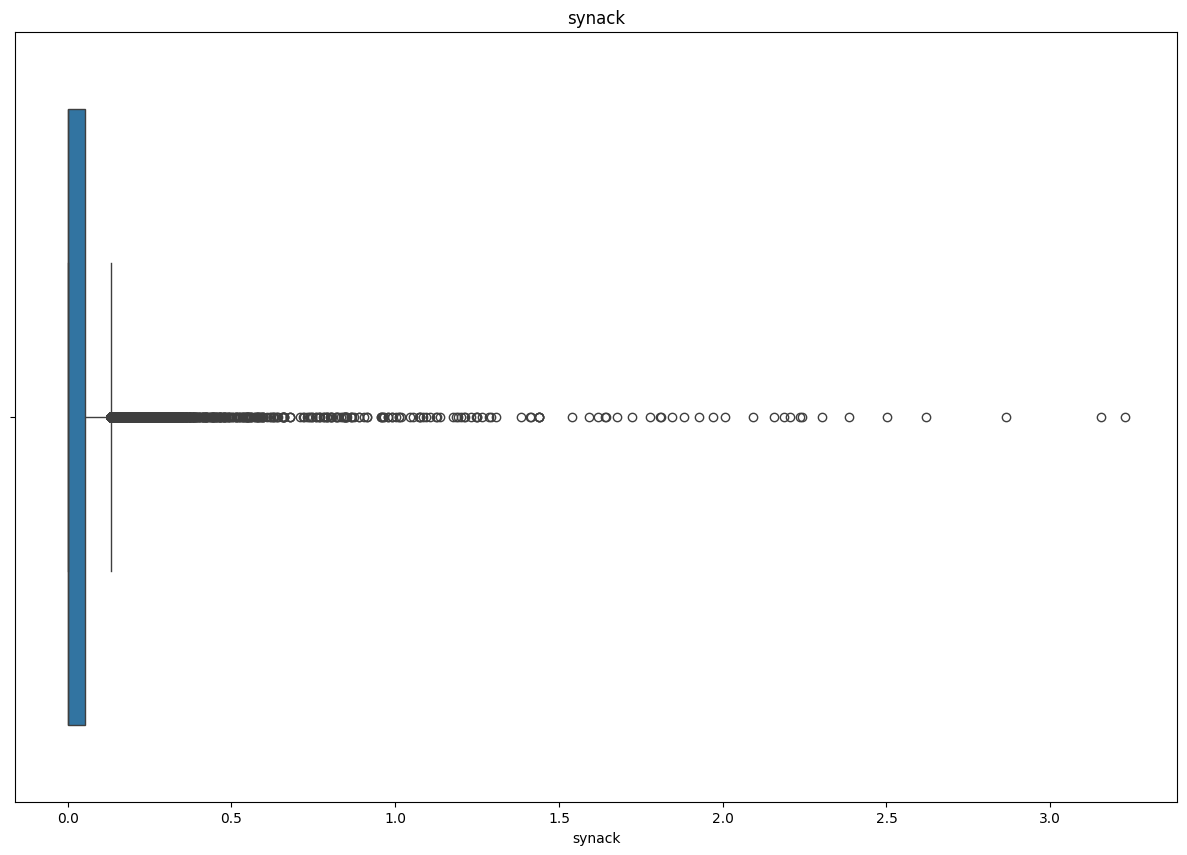

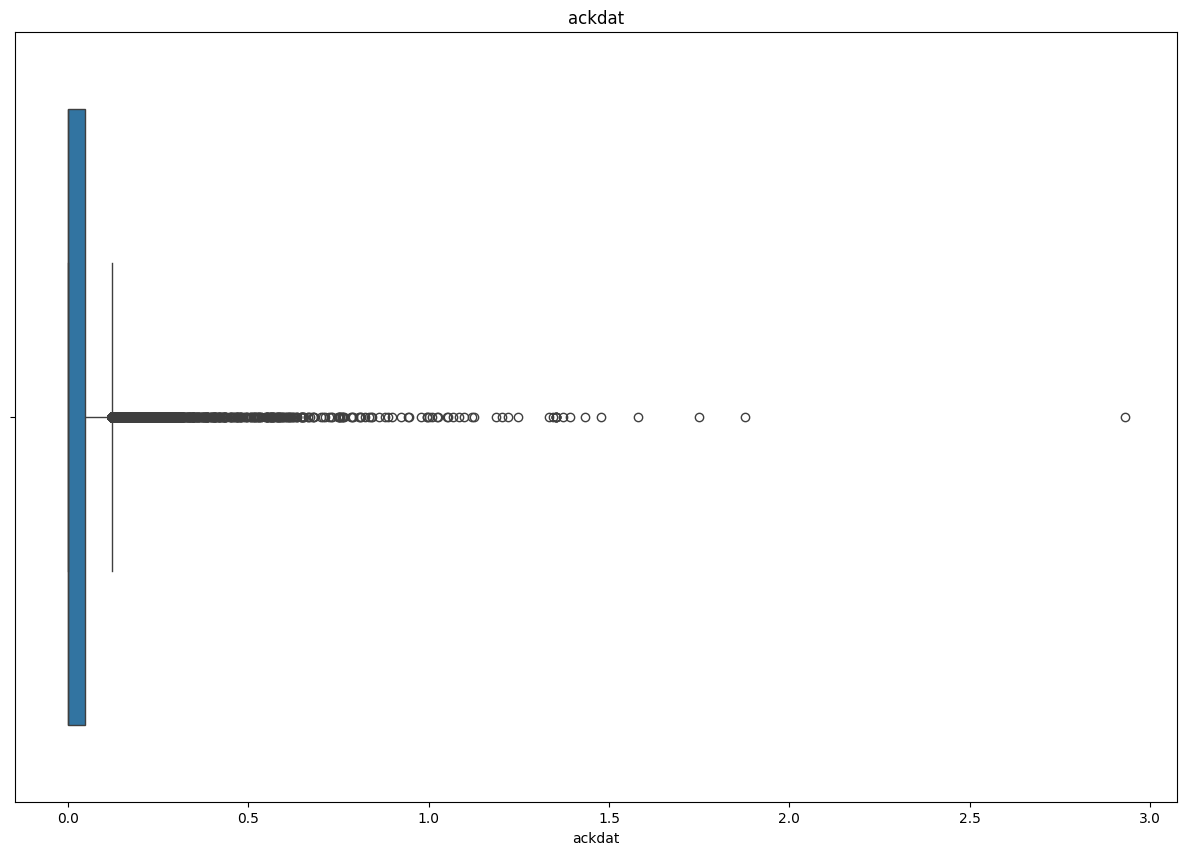

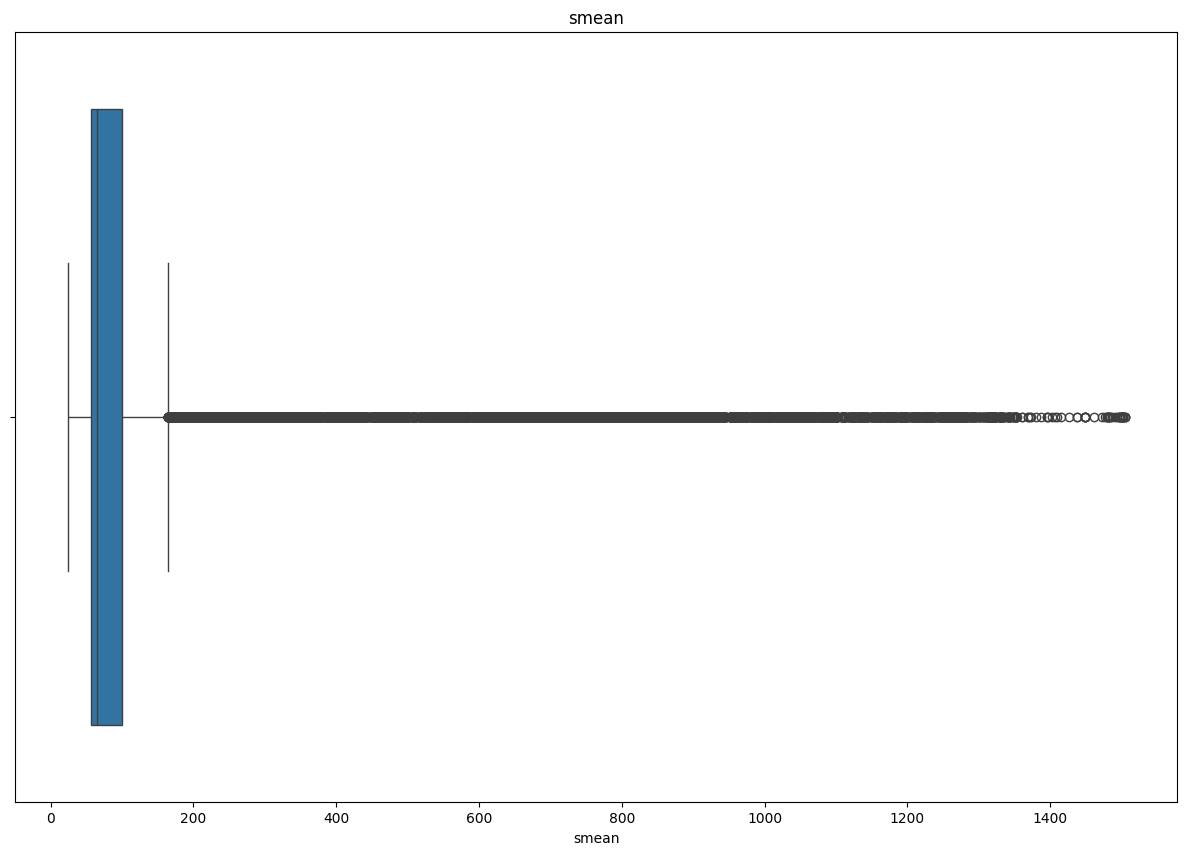

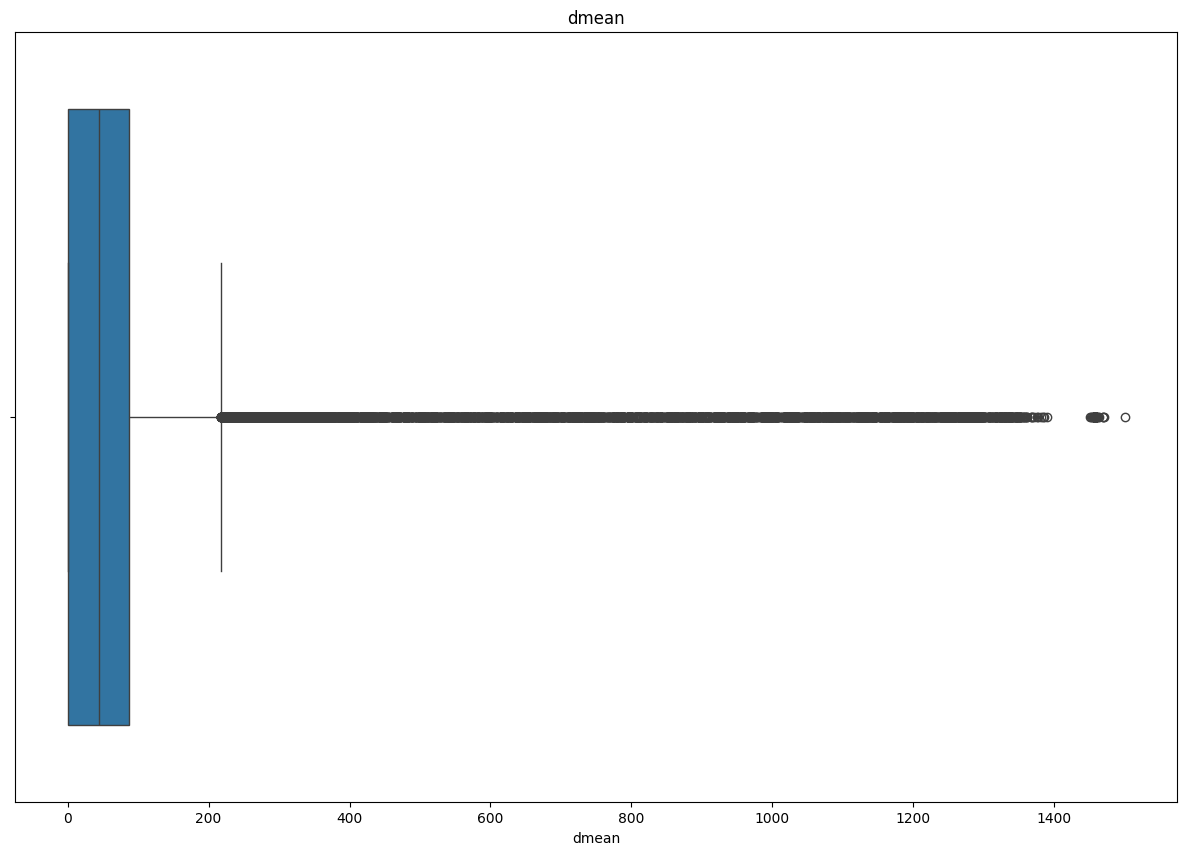

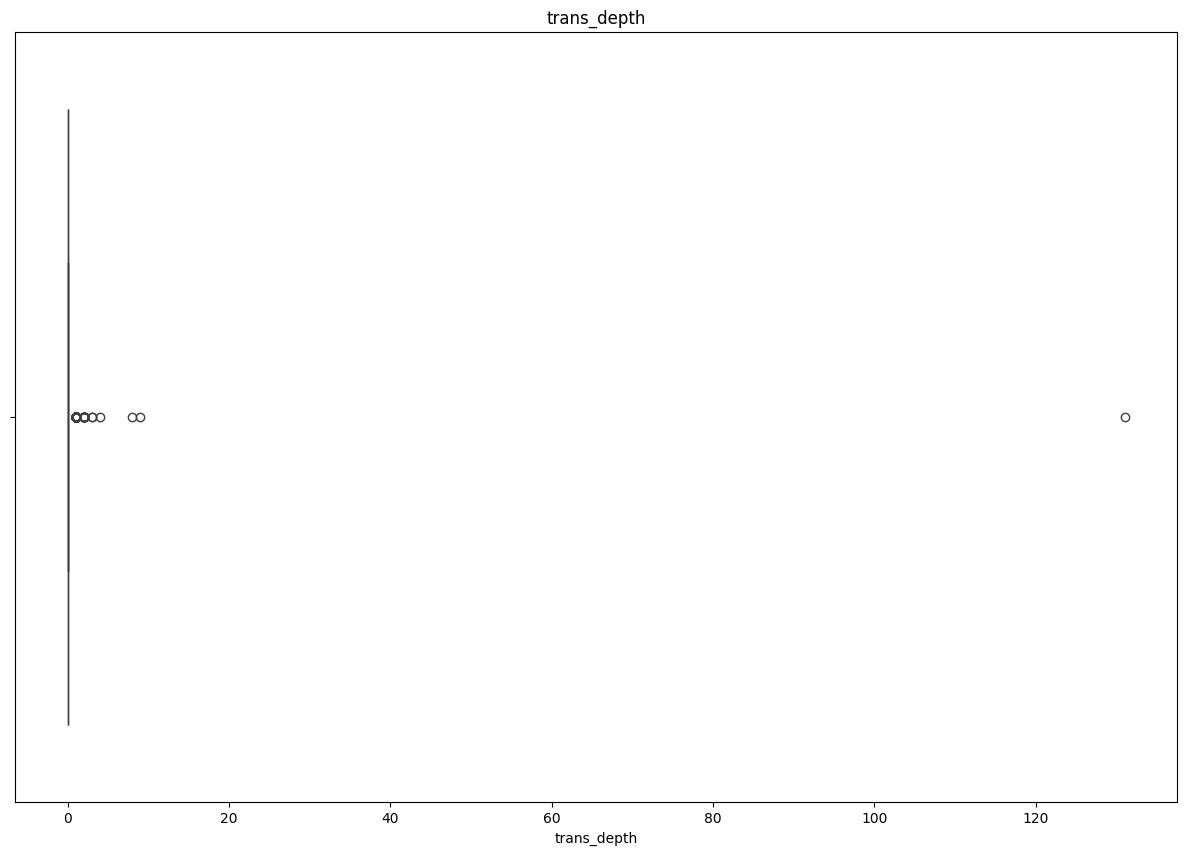

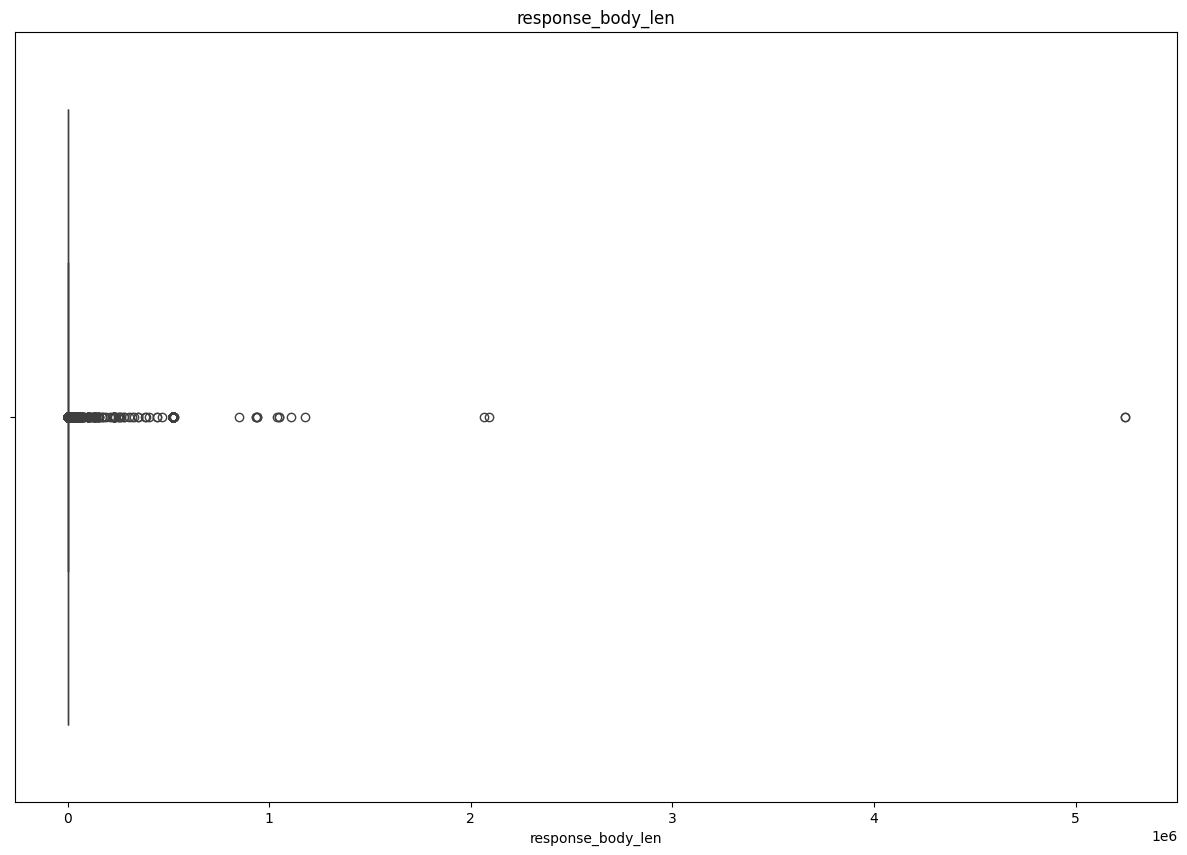

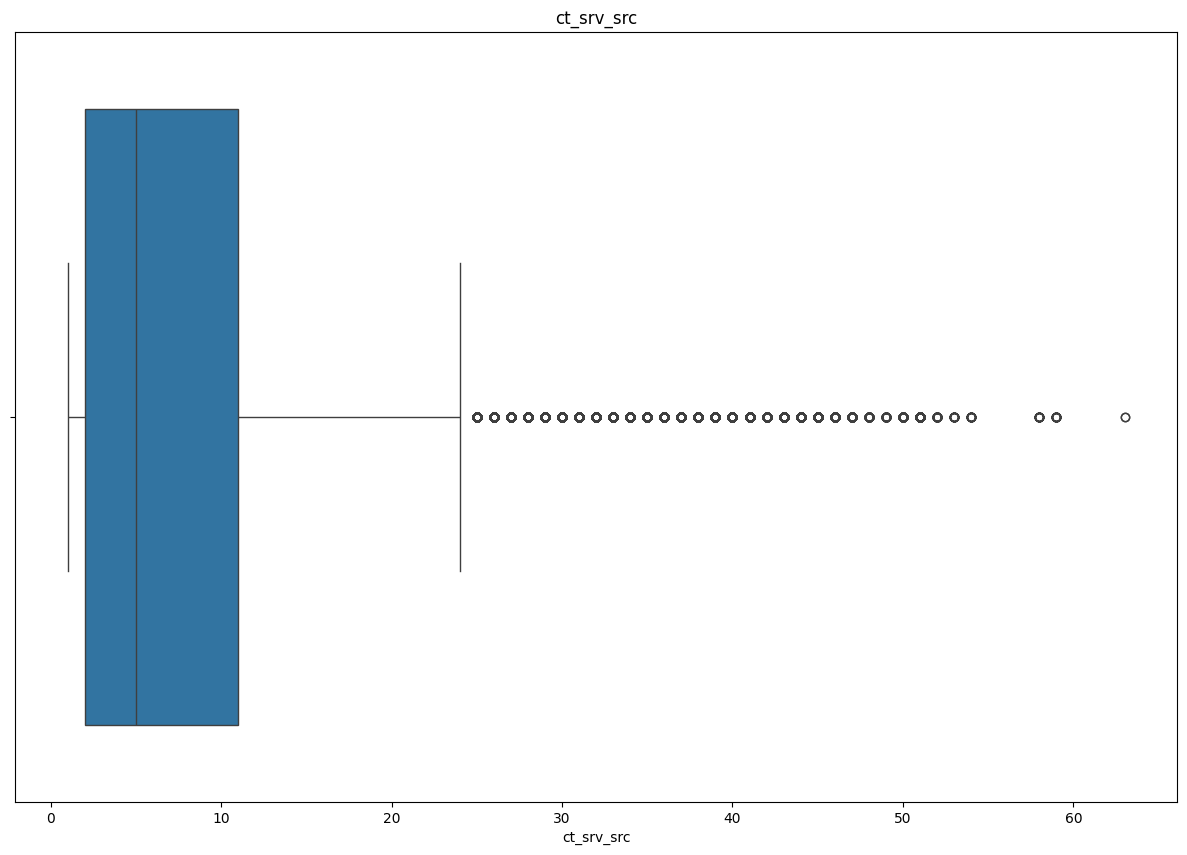

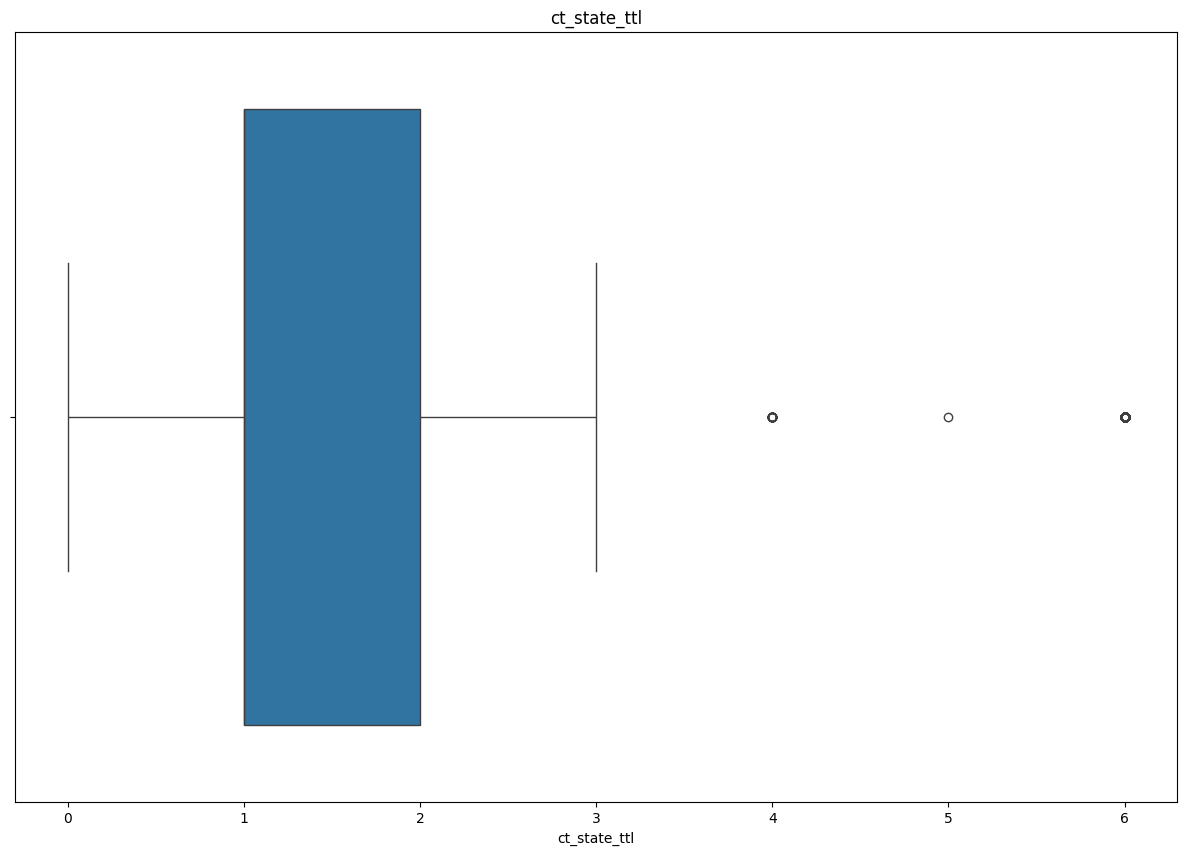

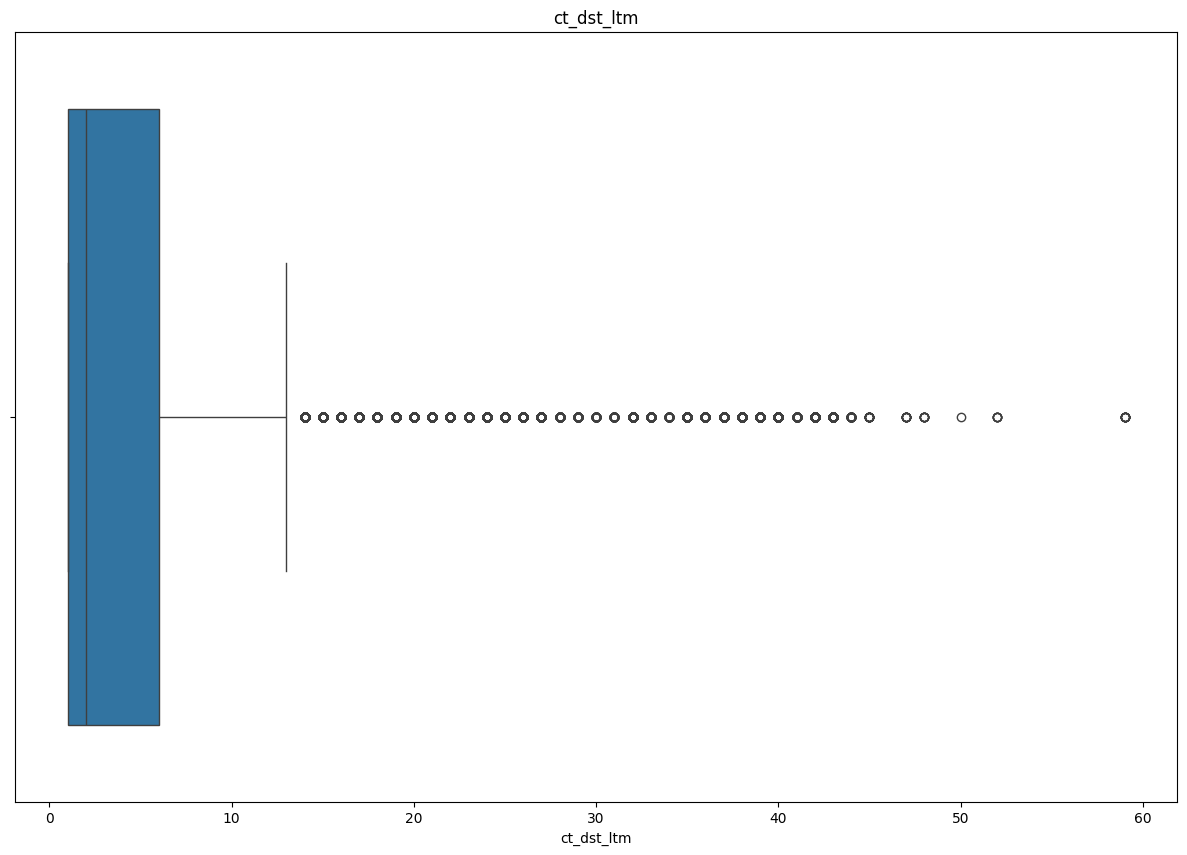

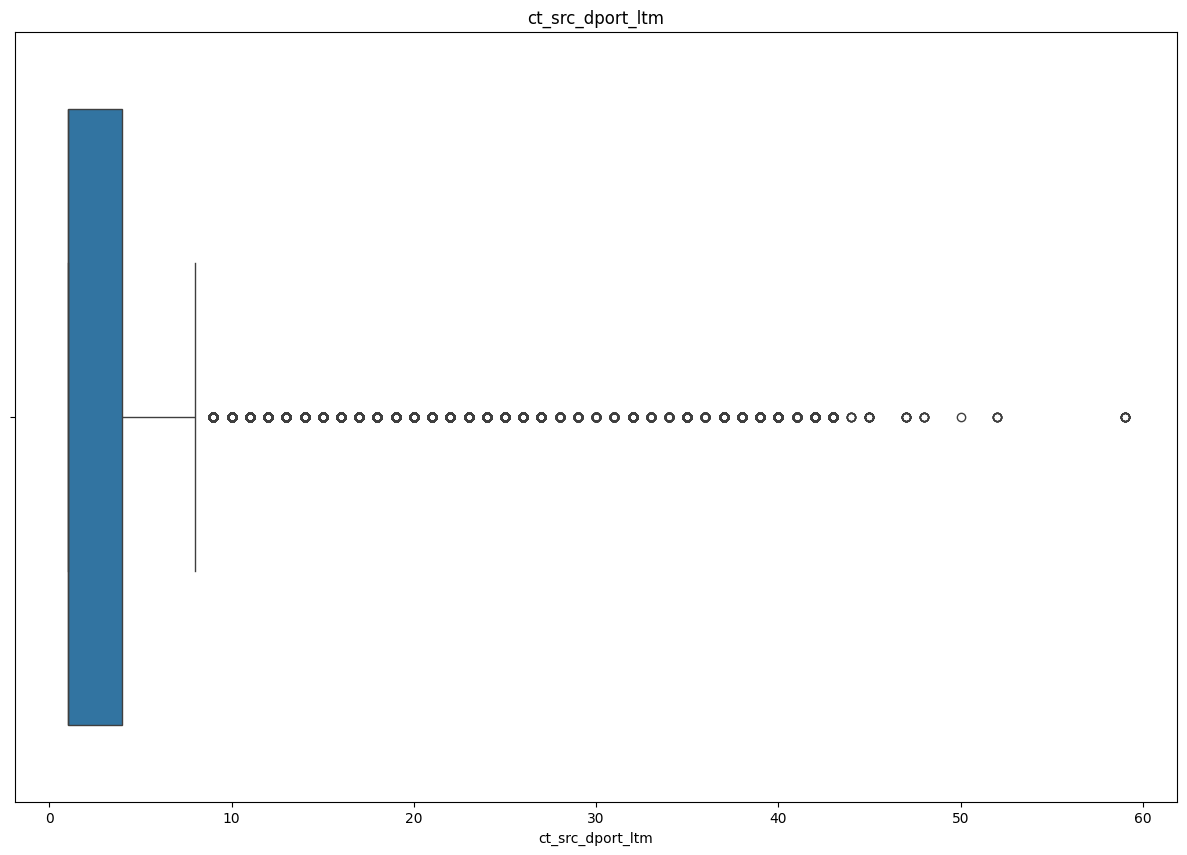

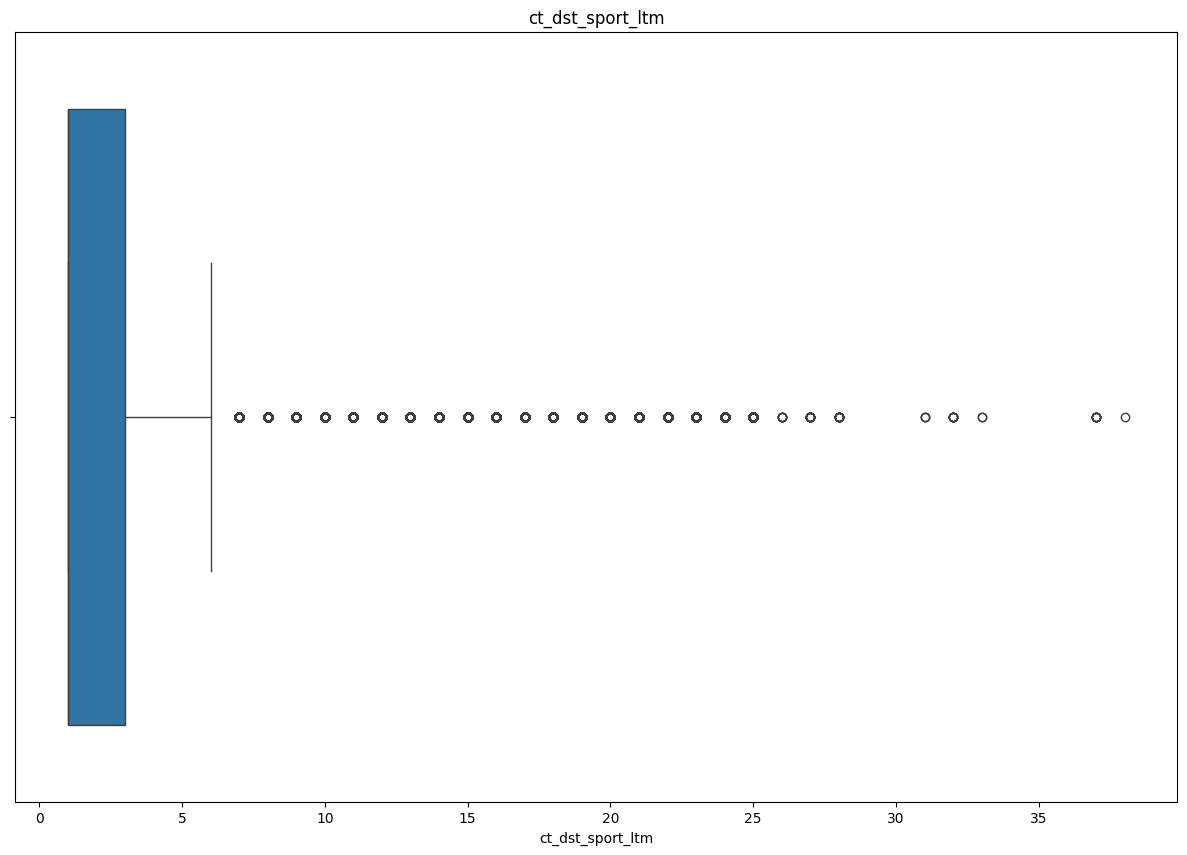

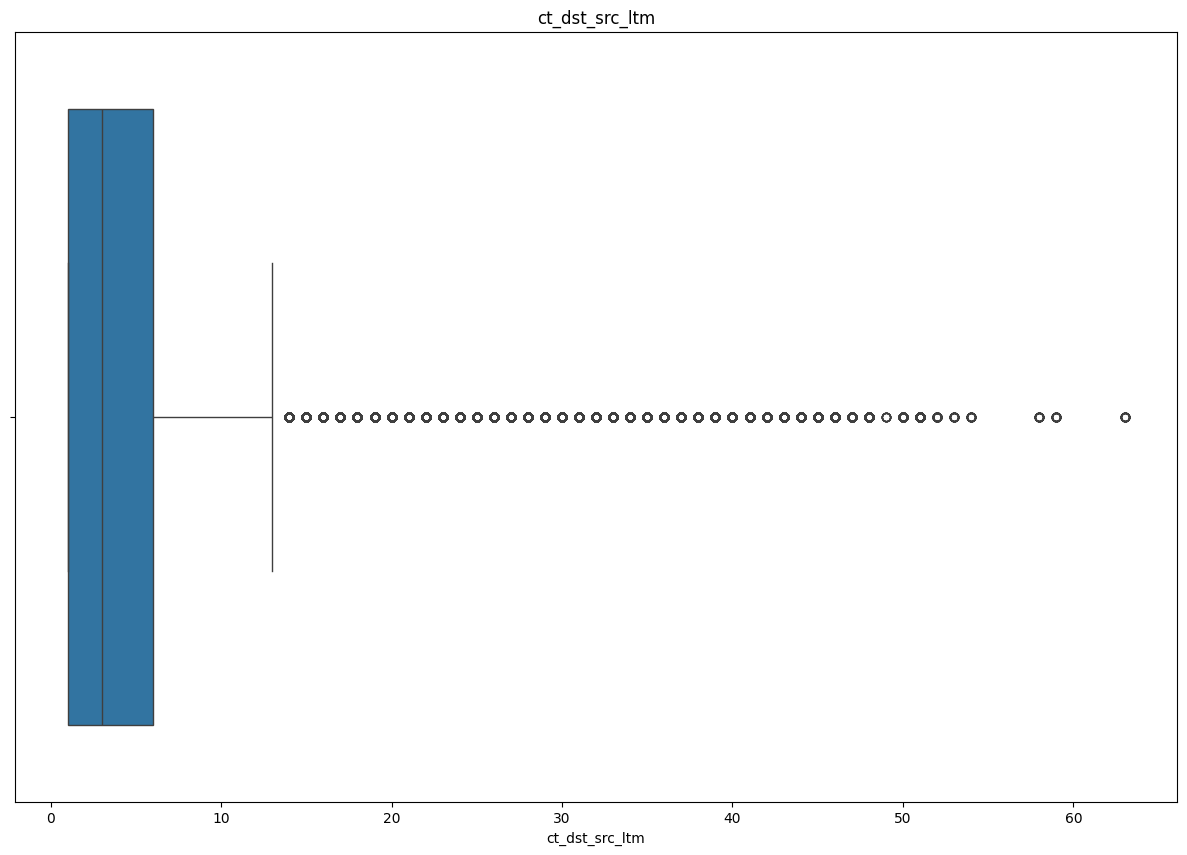

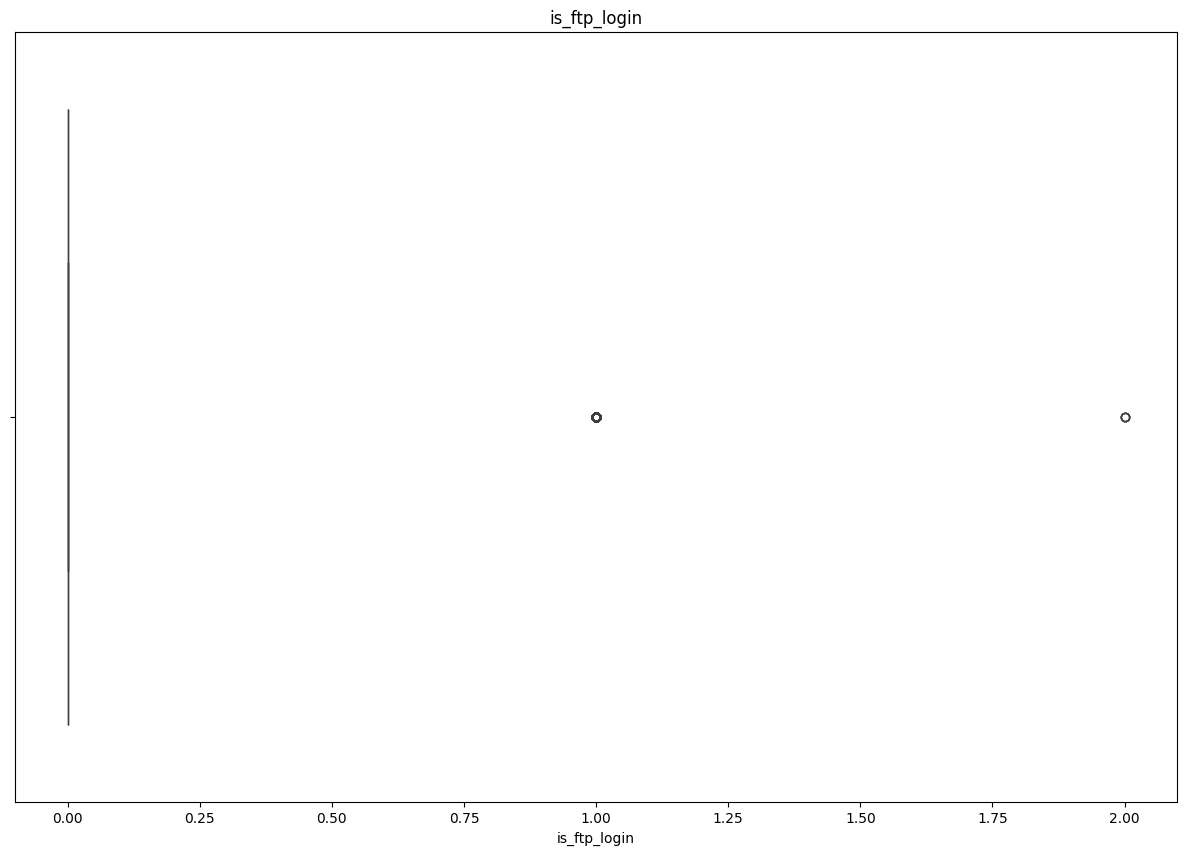

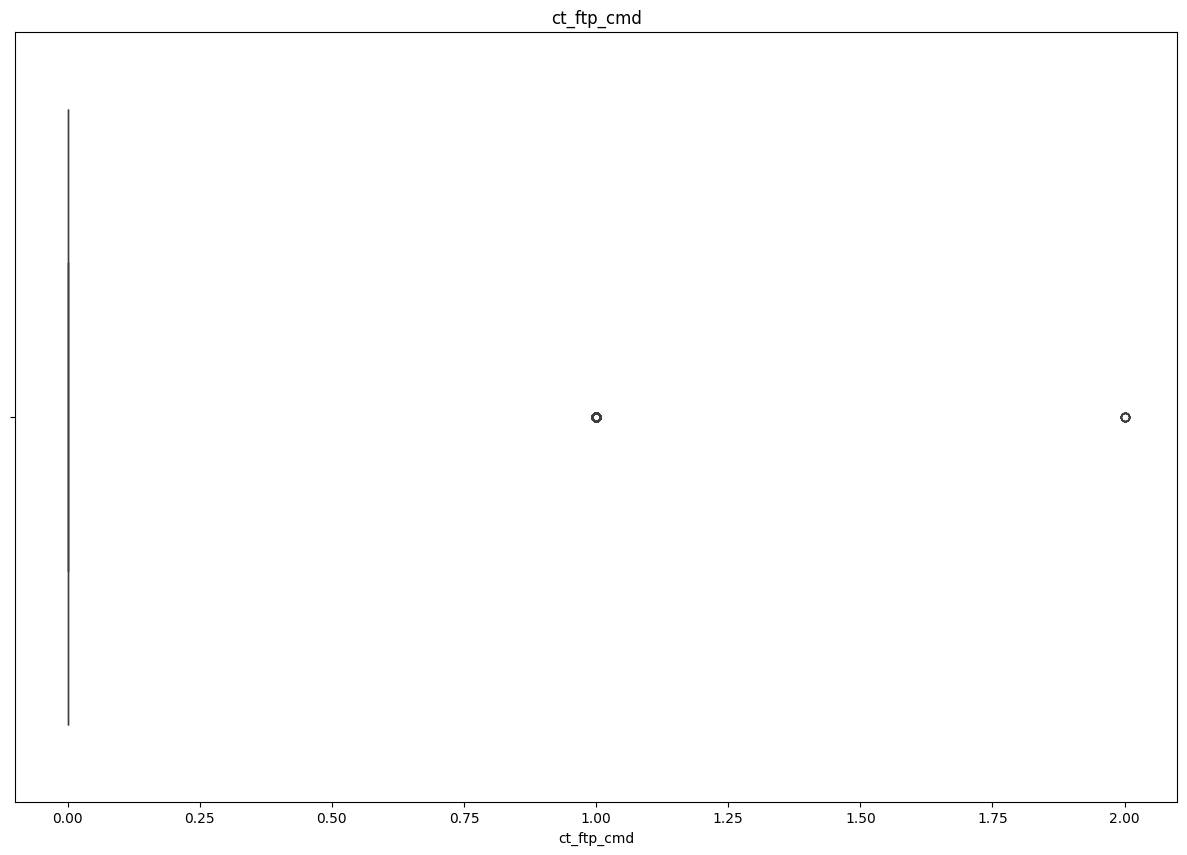

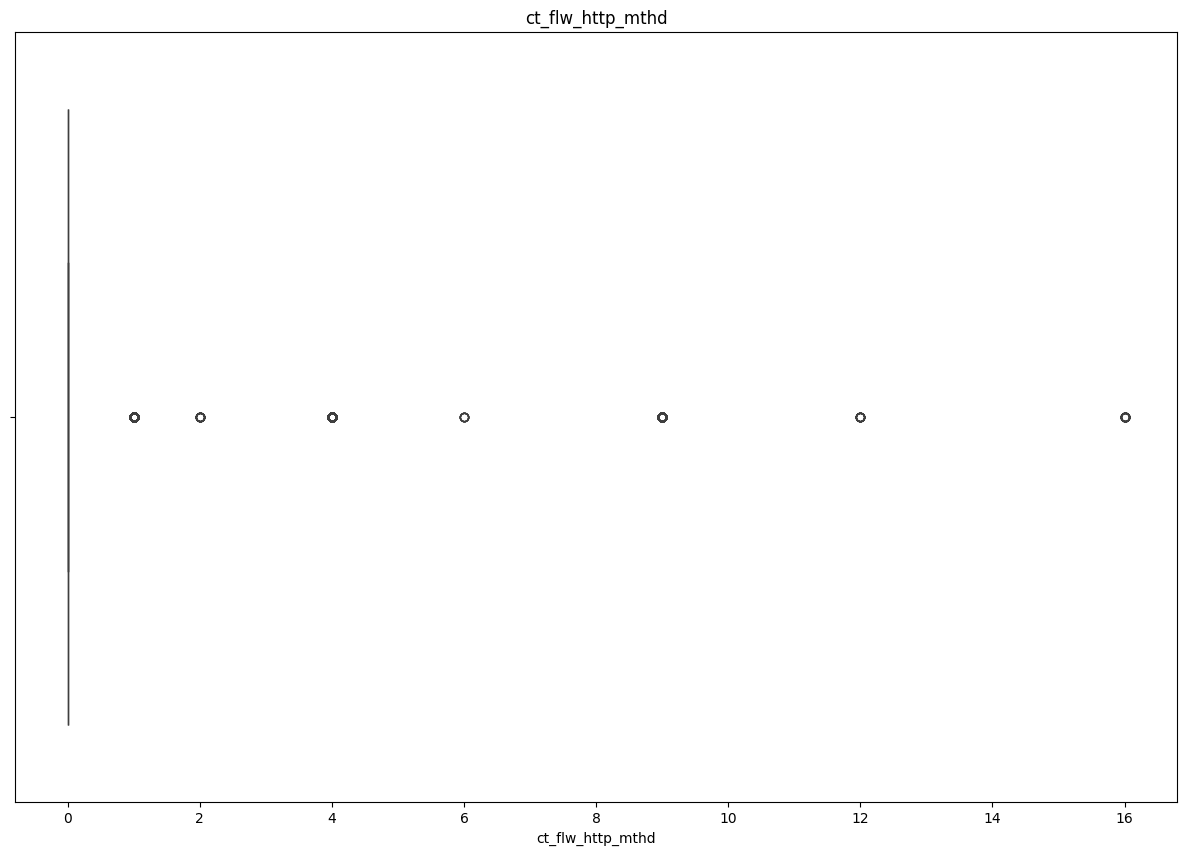

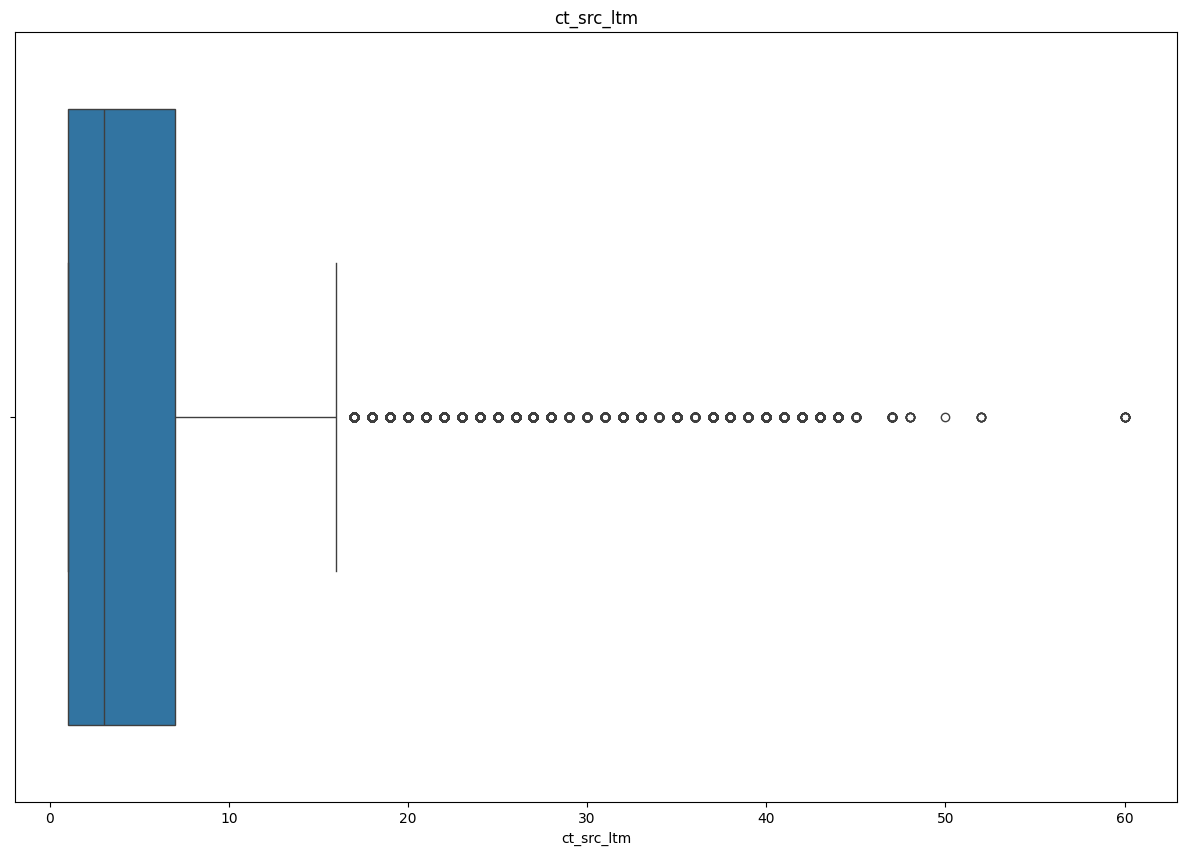

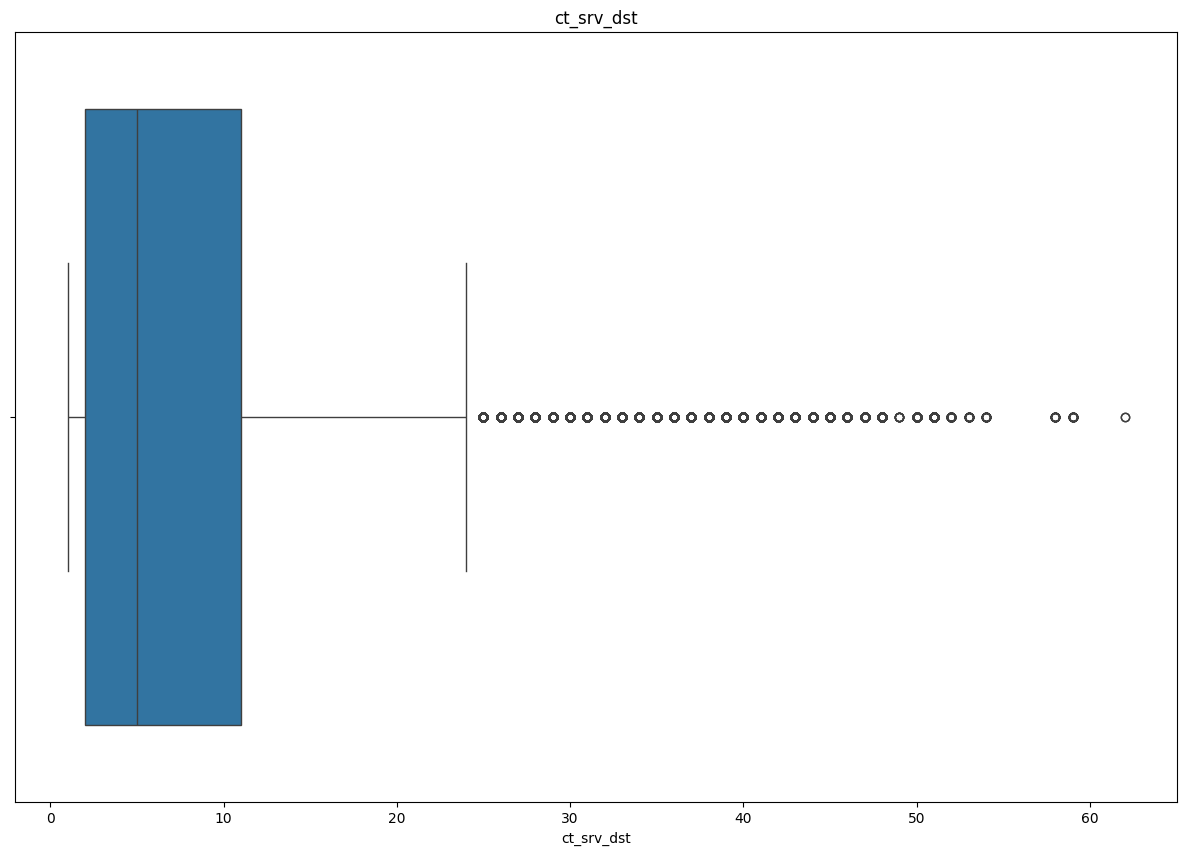

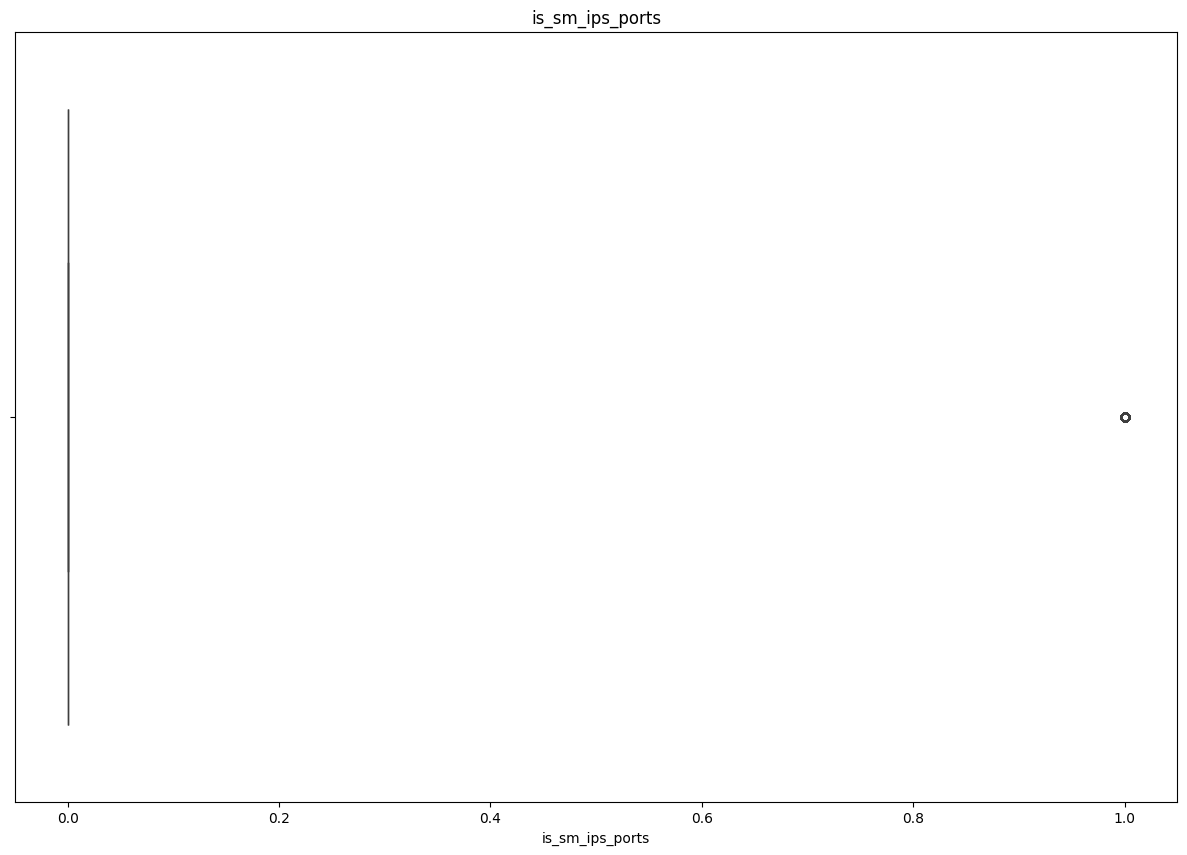

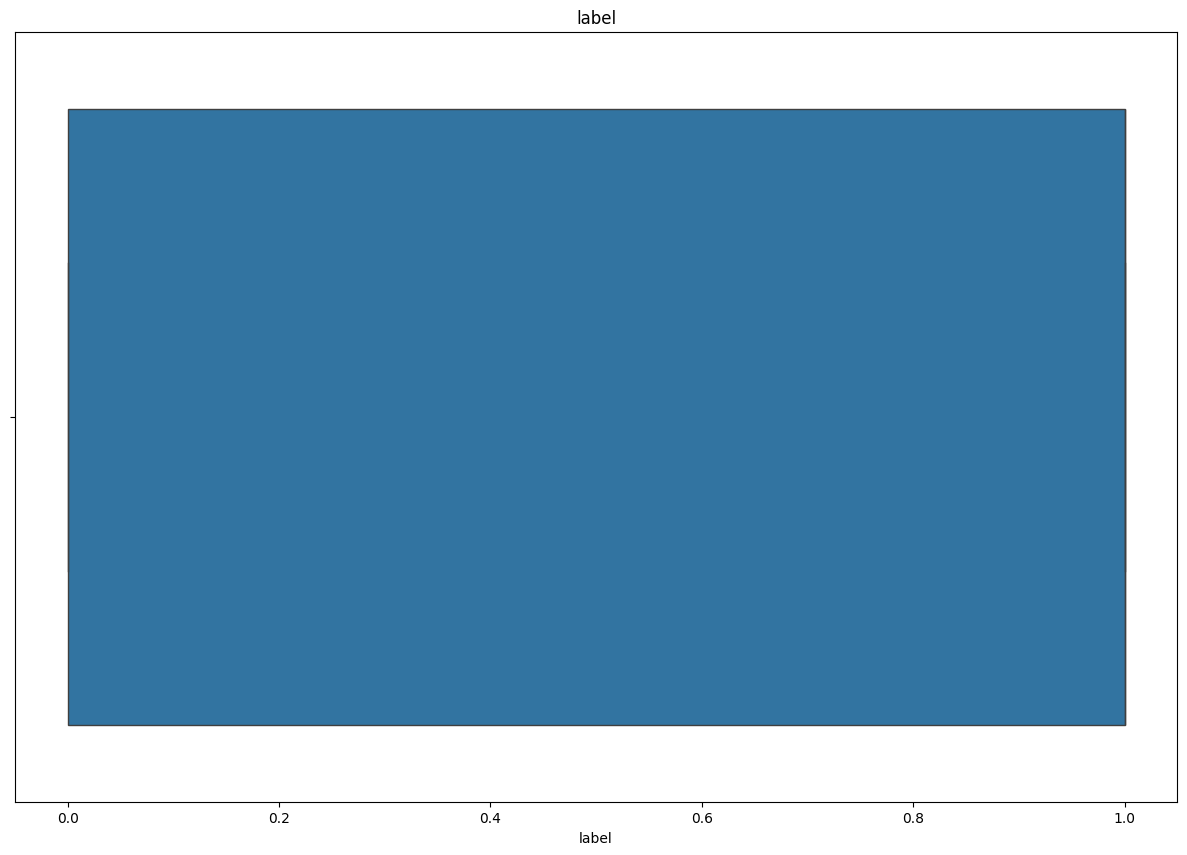

In [21]:
for col in num_col:
    plt.figure(figsize=(15,10))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## 2) Handle outliers (IQR capping)
We will:
- Cap outliers using IQR bounds (Q1 - 1.5*IQR, Q3 + 1.5*IQR)


In [22]:
# Identify numeric & categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Remove target from feature lists
if TARGET in num_cols: num_cols.remove(TARGET)
if TARGET in cat_cols: cat_cols.remove(TARGET)

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))
print("Example cat cols:", cat_cols[:5])


Numeric cols: 41
Categorical cols: 3
Example cat cols: ['proto', 'service', 'state']


In [23]:
# Outlier capping (IQR) for numeric columns
df_capped = df.copy()

for col in num_cols:
    q1 = df_capped[col].quantile(0.25)
    q3 = df_capped[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_capped[col] = np.clip(df_capped[col], lower, upper)

df = df_capped
df.describe(include="all").T.head(10)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,82332.0,NaN,NaN,NaN,41166.5,23767.345519,1.0,20583.75,41166.5,61749.25,82332.0
dur,82332.0,NaN,NaN,NaN,0.40905,0.576835,0.0,0.000008,0.014138,0.71936,1.798389
proto,82332,131,tcp,43095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,82332,13,-,47153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,82332,7,FIN,39339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spkts,82332.0,NaN,NaN,NaN,9.033146,8.603447,1.0,2.0,6.0,12.0,27.0
dpkts,82332.0,NaN,NaN,NaN,6.839637,8.48484,0.0,0.0,2.0,10.0,25.0
sbytes,82332.0,NaN,NaN,NaN,927.276636,1009.309169,24.0,114.0,534.0,1280.0,3029.0
dbytes,82332.0,NaN,NaN,NaN,624.957696,875.192663,0.0,0.0,178.0,956.0,2390.0
rate,82332.0,NaN,NaN,NaN,67389.192887,92500.591893,0.0,28.606114,2650.176667,111111.1072,277734.858829


## 3) Split: Train / Test then Train / Validation
We will keep test **completely unseen**, then create a validation set from the training set.


In [24]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train label distribution:", y_train.value_counts().to_dict())


Train: (52692, 44) Val: (13173, 44) Test: (16467, 44)
Train label distribution: {'Normal': 23680, 'Generic': 12078, 'Exploits': 7124, 'Fuzzers': 3880, 'DoS': 2617, 'Reconnaissance': 2238, 'Analysis': 433, 'Backdoor': 373, 'Shellcode': 241, 'Worms': 28}


 LabelEncoding + Scaling + SMOTE


In [25]:
# --- Copy data to avoid SettingWithCopy warnings
Xtr_A = X_train.copy()
Xva_A = X_val.copy()
Xte_A = X_test.copy()

# LabelEncode categorical features (fit on train only)
feature_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    Xtr_A[col] = le.fit_transform(Xtr_A[col].astype(str))
    Xva_A[col] = le.transform(Xva_A[col].astype(str))
    Xte_A[col] = le.transform(Xte_A[col].astype(str))
    feature_encoders[col] = le

# Scale numeric features (fit on train only)
scaler_A = StandardScaler()
Xtr_A[num_cols] = scaler_A.fit_transform(Xtr_A[num_cols])
Xva_A[num_cols] = scaler_A.transform(Xva_A[num_cols])
Xte_A[num_cols] = scaler_A.transform(Xte_A[num_cols])

In [26]:
# SMOTE on training only
smote = SMOTE(random_state=42)
Xtr_A_res, ytr_A_res = smote.fit_resample(Xtr_A, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(ytr_A_res))


Before SMOTE: Counter({'Normal': 23680, 'Generic': 12078, 'Exploits': 7124, 'Fuzzers': 3880, 'DoS': 2617, 'Reconnaissance': 2238, 'Analysis': 433, 'Backdoor': 373, 'Shellcode': 241, 'Worms': 28})
After SMOTE: Counter({'Exploits': 23680, 'Generic': 23680, 'Normal': 23680, 'Reconnaissance': 23680, 'DoS': 23680, 'Fuzzers': 23680, 'Backdoor': 23680, 'Shellcode': 23680, 'Analysis': 23680, 'Worms': 23680})


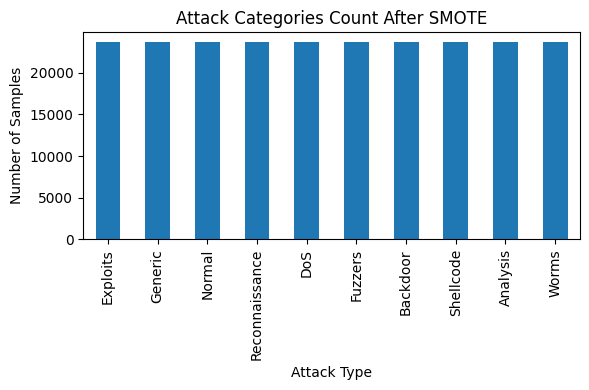

In [27]:
plt.figure(figsize=(6,4))

ytr_A_res.value_counts().plot(kind="bar")

plt.title("Attack Categories Count After SMOTE")
plt.xlabel("Attack Type")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()


In [28]:
# Encode target (consistent mapping for train/val/test)
target_encoder = LabelEncoder()
ytr_A = target_encoder.fit_transform(ytr_A_res)
yva_A = target_encoder.transform(y_val)
yte_A = target_encoder.transform(y_test)

num_classes = len(target_encoder.classes_)
print("Classes:", list(target_encoder.classes_))
print("num_classes:", num_classes)


Classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']
num_classes: 10


In [29]:
# One-hot for Keras softmax
ytr_A_oh = keras.utils.to_categorical(ytr_A, num_classes=num_classes)
yva_A_oh = keras.utils.to_categorical(yva_A, num_classes=num_classes)
yte_A_oh = keras.utils.to_categorical(yte_A, num_classes=num_classes)

Xtr_A_res = Xtr_A_res.values.astype("float32")
Xva_A = Xva_A.values.astype("float32")
Xte_A = Xte_A.values.astype("float32")


# DLL model

In [51]:
def build_model_A(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model_A = build_model_A(Xtr_A_res.shape[1], num_classes)
model_A.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,666 (57.29 KB)

 Trainable params: 14,666 (57.29 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
callbacks_A = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)
]

history_A = model_A.fit(
    Xtr_A_res, ytr_A_oh,
    validation_data=(Xva_A, yva_A_oh),
    epochs=40, # sae epoches into 40 cuz we noticed that it stops and dosnt improve from 21
    batch_size=256,
    verbose=1
)


Epoch 1/40
925/925 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1441 - loss: 3.3425 - val_accuracy: 0.7461 - val_loss: 0.7064
Epoch 2/40
925/925 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.5114 - loss: 1.3131 - val_accuracy: 0.8614 - val_loss: 0.4132
Epoch 3/40
925/925 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6758 - loss: 0.8772 - val_accuracy: 0.8646 - val_loss: 0.3893
Epoch 4/40
925/925 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7087 - loss: 0.7823 - val_accuracy: 0.8668 - val_loss: 0.3712
Epoch 5/40
925/925 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7262 - loss: 0.7315 - val_accuracy: 0.8671 - val_loss: 0.3708
Epoch 6/40
925/925 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7346 - loss: 0.6939 - val_accuracy: 0.8676 - val_loss: 0.3671
Epoch 7/40
925/925 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7403 - loss: 0.6758 - val_accuracy: 0.8694 - val_loss: 0.3639
Epoch 8/40
925/925 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7451 - loss: 0.6597 - val_accuracy: 0.

diffrent learning rate values (0.0001 ,0.0005 and 0.001) were evaluated for Model A. all configurations achieved similar overall performance with an accuracy of approximately 88% and comparable F1-scores. However, the learning rate of 0.001 resulted in slightly higher accuracy and improved recall for some minority attack classes, while also converging faster. Therefore, a learning rate of 0.001 was selected as the final configuration.

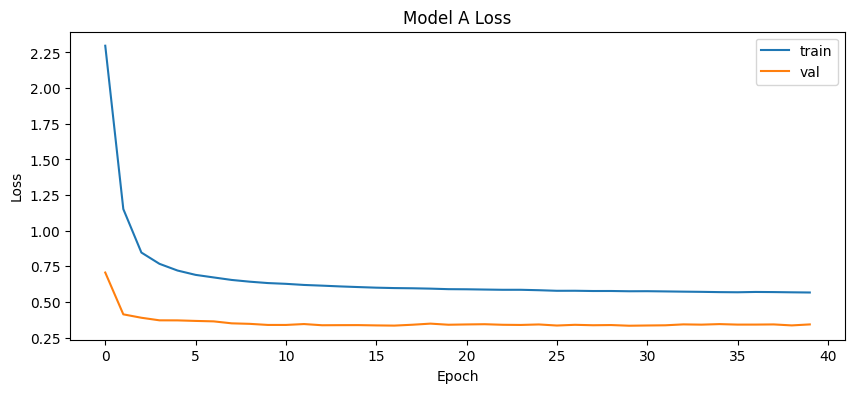

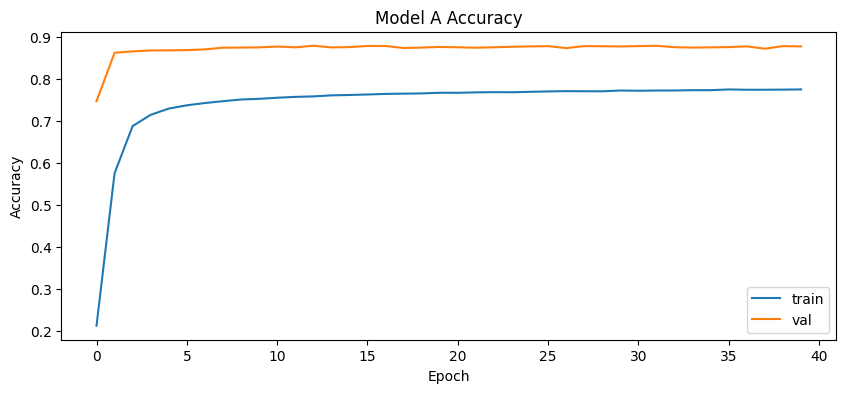

In [53]:
# Plot learning curves
plt.figure(figsize=(10,4))
plt.plot(history_A.history["loss"], label="train")
plt.plot(history_A.history["val_loss"], label="val")
plt.title("Model A Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history_A.history["accuracy"], label="train")
plt.plot(history_A.history["val_accuracy"], label="val")
plt.title("Model A Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Model A - Test Accuracy: 0.8774 | Test Loss: 0.3359

Classification Report (Model A):
                precision    recall  f1-score   support

      Analysis       0.14      0.12      0.13       135
      Backdoor       0.14      0.78      0.23       117
           DoS       0.41      0.64      0.50       818
      Exploits       0.87      0.55      0.68      2227
       Fuzzers       0.91      0.75      0.82      1212
       Generic       1.00      0.96      0.98      3774
        Normal       1.00      1.00      1.00      7400
Reconnaissance       0.78      0.84      0.81       699
     Shellcode       0.30      0.75      0.42        76
         Worms       0.12      0.22      0.16         9

      accuracy                           0.88     16467
     macro avg       0.57      0.66      0.57     16467
  weighted avg       0.92      0.88      0.89     16467



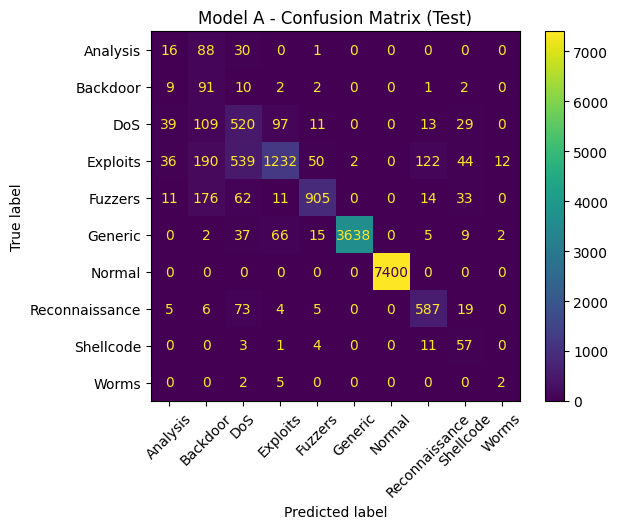

In [54]:
# Test evaluation (Model A)
test_loss_A, test_acc_A = model_A.evaluate(Xte_A, yte_A_oh, verbose=0)
print(f"Model A - Test Accuracy: {test_acc_A:.4f} | Test Loss: {test_loss_A:.4f}")

y_pred_A = model_A.predict(Xte_A, verbose=0).argmax(axis=1)

print("\nClassification Report (Model A):")
print(classification_report(yte_A, y_pred_A, target_names=target_encoder.classes_))

cm_A = confusion_matrix(yte_A, y_pred_A)
disp_A = ConfusionMatrixDisplay(cm_A, display_labels=target_encoder.classes_)
disp_A.plot(xticks_rotation=45)
plt.title("Model A - Confusion Matrix (Test)")
plt.show()


The confusion matrix shows that the deep learning model achieves excellent performance in detecting Normal and Generic traffic, while some confusion exists between attack categories with similar traffic patterns such as DoS and Exploits. Minority classes like Worms and Shellcode remain challenging due to limited samples.

# ML Baseline (RandomForest)
This is a simple baseline to compare between DL and classic ML.

Random Forest was used as a baseline model due to its robustness to correlated features and ability to handle complex decision boundaries.



In [40]:
RF_Model =  RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

RF_Model.fit(Xtr_A_res, ytr_A_res)
y_pred_rf = RF_Model.predict(Xte_A)

The Random Forest model achieved an accuracy of approximately 89% with comparable precision, recall, and F1-score. Several hyperparameter combinations were experimentally evaluated in an attempt to further improve performance. However, these combinations did not result in a meaningful performance gain, while significantly increasing the training time and computational cost. Therefore, those hyperparameter configuration was selected as the final model, as it provides a better overall balance between performance efficiency and computational cost.

RandomForest - Test Accuracy: 0.8909

Classification Report (RandomForest):
                precision    recall  f1-score   support

      Analysis       0.07      0.07      0.07       135
      Backdoor       0.02      0.03      0.03       117
           DoS       0.43      0.50      0.46       818
      Exploits       0.72      0.71      0.72      2227
       Fuzzers       0.83      0.80      0.82      1212
       Generic       1.00      0.97      0.98      3774
        Normal       1.00      1.00      1.00      7400
Reconnaissance       0.87      0.81      0.84       699
     Shellcode       0.56      0.70      0.62        76
         Worms       0.43      0.33      0.38         9

      accuracy                           0.89     16467
     macro avg       0.59      0.59      0.59     16467
  weighted avg       0.90      0.89      0.89     16467



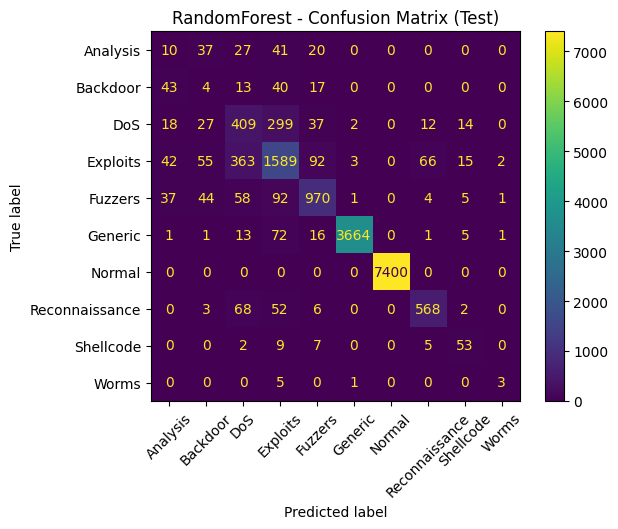

RandomForest Test Results
Accuracy : 0.8909
Precision: 0.8988
Recall   : 0.8909
F1-score : 0.8945


In [41]:
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"RandomForest - Test Accuracy: {acc_rf:.4f}")
print("\nClassification Report (RandomForest):")
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=target_encoder.classes_)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=target_encoder.classes_)
disp_rf.plot(xticks_rotation=45)
plt.title("RandomForest - Confusion Matrix (Test)")
plt.show()


prec_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf   = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print("RandomForest Test Results")
print("Accuracy :", round(acc_rf, 4))
print("Precision:", round(prec_rf, 4))
print("Recall   :", round(rec_rf, 4))
print("F1-score :", round(f1_rf, 4))


The Random Forest model achieves high overall accuracy and performs exceptionally well on majority classes such as Normal and Generic traffic. However, its performance degrades significantly on minority attack categories like Analysis, Backdoor, and Worms, indicating sensitivity to class imbalance

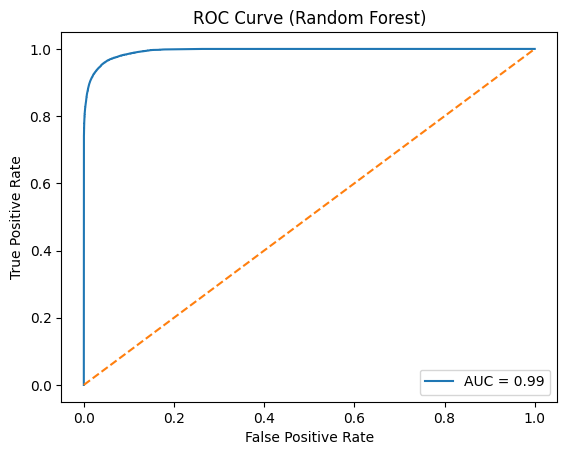

In [42]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_score = RF_Model.predict_proba(Xte_A)

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Random Forest)")
plt.legend()
plt.show()


The ROC curve shows excellent discriminative ability of the Random Forest model, with an AUC of 0.99, indicating a very strong capability to distinguish between attack and normal traffic across different thresholds.